---
title: Bayesian HMM GLM
subtitle: Hidden Markov Models with a generalized linear model in the emission probabilities 
format: html
jupyter: python3
editor_options:
       chunk_output_type: inline
---

# Import and clean data

In [1]:
import pandas as pd
import numpy as np
from hmmlearn import hmm
import matplotlib.pyplot as plt
from pyprojroot import here
import pyro
import pyro.distributions as dist
import pyro.distributions.constraints as constraints
from pyro.infer import SVI, TraceEnum_ELBO
from pyro.optim import Adam
from scipy.stats import poisson
import torch
import seaborn as sns

data = pd.read_csv(here("data/recent_donations.csv"))
data

# remove columns y_2020 to y_2023
# data = data.drop(columns=["y_2020", "y_2021", "y_2022", "y_2023"])

,unique_number,class_year,birth_year,first_donation_year,gender,y_2009,y_2010,y_2011,y_2012,y_2013,y_2014,y_2015,y_2016,y_2018,y_2019,y_2017,y_2020,y_2021,y_2022,y_2023
0,26308560,"(1960,1970]",1965,1985,M,0,0,0,0,0,0,0,0,0,0,0,1,1,3,1
1,26309283,"(1960,1970]",1966,2002,M,2,1,2,2,1,1,3,3,4,1,3,3,3,3,4
2,26317365,"(1960,1970]",1961,1984,M,4,2,3,3,3,4,3,3,2,3,3,2,0,1,0
3,26318451,"(1960,1970]",1967,1989,M,0,3,3,4,4,4,2,3,3,1,2,3,1,0,0
4,26319465,"(1960,1970]",1964,1994,F,1,2,2,1,2,1,1,0,0,2,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9231,27220599,"(1970,1980]",1980,2022,M,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0
9232,27220806,"(2000,2010]",2002,2022,M,0,0,0,0,0,0,0,0,0,0,0,0,0,2,3
9233,27221247,"(1990,2000]",2000,2022,F,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0
9234,27221274,"(1960,1970]",1966,2022,F,0,0,0,0,0,0,0,0,0,0,0,0,0,2,3


In [2]:
# ───────────────────────────────────────────────────────────────
#  Required libraries
# ───────────────────────────────────────────────────────────────
import polars as pl
import numpy as np
import torch

# ───────────────────────────────────────────────────────────────
# 1. Load data
# ───────────────────────────────────────────────────────────────
df = pl.from_pandas(data)                # or pl.read_csv("file.csv")

# ───────────────────────────────────────────────────────────────
# 2. Observed counts   obs  ∈  ℕ^{N×T}
# ───────────────────────────────────────────────────────────────
year_cols = sorted([c for c in df.columns if c.startswith("y_")])
T = len(year_cols)
obs = (df.select(year_cols)
         .fill_null(0)
         .to_numpy()
         .astype(int))                   # (N,T)

# ───────────────────────────────────────────────────────────────
# 3. Fixed covariates (for π)
# ───────────────────────────────────────────────────────────────
df = df.with_columns([
    (pl.col("gender") == "F").cast(pl.Int8).alias("gender_code"),
    ((pl.col("birth_year") - pl.col("birth_year").mean()) /
     pl.col("birth_year").std()).alias("birth_year_norm")
])

birth_year_norm = df["birth_year_norm"].to_numpy()        # (N,)
gender_code     = df["gender_code"].to_numpy()            # (N,)

# π-covariate matrix  (N,2)
cov_init = np.stack([birth_year_norm, gender_code], axis=1)

# ───────────────────────────────────────────────────────────────
# 4. Dynamic covariates (for A)
# ───────────────────────────────────────────────────────────────
years_num  = np.array([int(c[2:]) for c in year_cols])    # [2009, …, 2023]
ages       = years_num[None, :] - df["birth_year"].to_numpy()[:, None]
ages_norm  = (ages - ages.mean()) / ages.std()            # (N,T)

covid_mask = np.isin(years_num, [2020, 2021, 2022]).astype(float)  # (T,)
covid_years = np.tile(covid_mask, (df.height, 1))          # (N,T)

# A-covariate tensor (N,T,2)
cov_tran = np.stack([ages_norm, covid_years], axis=2)

# ───────────────────────────────────────────────────────────────
# 5. Torch tensors
# ───────────────────────────────────────────────────────────────
obs_torch      = torch.tensor(obs,      dtype=torch.long)
cov_init_torch = torch.tensor(cov_init, dtype=torch.float)   # (N,2)
cov_tran_torch = torch.tensor(cov_tran, dtype=torch.float)   # (N,T,2)

# ───────────────────────────────────────────────────────────────
# 6. Emission covariates (for emission GLMs in HMM)
#    (N, T, 4): [birth_year_norm, gender_code, ages_norm, covid_years]
# ───────────────────────────────────────────────────────────────

# Fixed part, repeated along time
# birth_year_norm_tile = np.repeat(birth_year_norm[:, None], T, axis=1)  # (N,T)
gender_code_tile     = np.repeat(gender_code[:, None],     T, axis=1)  # (N,T)

# Assemble emission covariate tensor (N,T,4)
cov_emission = np.stack(
    [gender_code_tile, ages_norm, covid_years],
    axis=2
)  # (N,T,4)

cov_emiss_torch = torch.tensor(cov_emission, dtype=torch.float)

print("Emission covariates:", cov_emiss_torch.shape)   # should be (N,T,4)

print("obs        :", obs_torch.shape)      # (N,T)
print("π covs     :", cov_init_torch.shape) # (N,2)
print("A covs     :", cov_tran_torch.shape) # (N,T,2)

Emission covariates: torch.Size([9236, 15, 3])
obs        : torch.Size([9236, 15])
π covs     : torch.Size([9236, 2])
A covs     : torch.Size([9236, 15, 2])


In [3]:
# ───────────────────────────────────────────────────────────────
#  Required libraries
# ───────────────────────────────────────────────────────────────
import polars as pl
import numpy as np
import torch

# ───────────────────────────────────────────────────────────────
# 1) Load data
# ───────────────────────────────────────────────────────────────
df = pl.from_pandas(data)  # oppure pl.read_csv("file.csv")

# ───────────────────────────────────────────────────────────────
# 2) Observed counts   obs ∈ ℕ^{N×T}
# ───────────────────────────────────────────────────────────────
year_cols = sorted([c for c in df.columns if c.startswith("y_")])
T = len(year_cols)
obs = (
    df.select(year_cols)
      .fill_null(0)
      .to_numpy()
      .astype(int)
)  # (N,T)

# ───────────────────────────────────────────────────────────────
# 3) Fixed covariates (for π)
# ───────────────────────────────────────────────────────────────
df = df.with_columns([
    (pl.col("gender") == "F").cast(pl.Int8).alias("gender_code"),
    ((pl.col("birth_year") - pl.col("birth_year").mean()) /
     pl.col("birth_year").std()).alias("birth_year_norm"),
])

gender_code     = df["gender_code"].to_numpy().astype(float)     # (N,)
birth_year_norm = df["birth_year_norm"].to_numpy().astype(float) # (N,)

# π-covariate matrix (N,2): [birth_year_norm, gender_code]
cov_init = np.stack([birth_year_norm, gender_code], axis=1).astype(np.float32)  # (N,2)

# ───────────────────────────────────────────────────────────────
# 4) Dynamic covariates (for A) — age bins (one-hot) + covid
# ───────────────────────────────────────────────────────────────
years_num  = np.array([int(c[2:]) for c in year_cols], dtype=int)    # [2009, …, 2023]
ages       = years_num[None, :] - df["birth_year"].to_numpy()[:, None]  # (N,T)

# Binning età per transizioni (adatta i break se serve)
age_bins = np.array([18, 26, 36, 46, 56, 61, 66, 200])  # 18–25, 26–35, …, 66+
ages_binned = np.digitize(ages, age_bins, right=False)   # (N,T), in {1..7}
n_agebins = len(age_bins) - 1
# One-hot su float32
ages_onehot = np.eye(n_agebins, dtype=np.float32)[np.clip(ages_binned - 1, 0, n_agebins-1)]  # (N,T,7)

# Covid indicator per anno
covid_mask  = np.isin(years_num, [2020, 2021, 2022]).astype(np.float32)  # (T,)
covid_years = np.tile(covid_mask, (obs.shape[0], 1)).astype(np.float32)  # (N,T)

# A-covariate tensor: [age_onehot(7), covid(1)] → (N,T,8)
cov_tran = np.concatenate([ages_onehot, covid_years[:, :, None]], axis=2).astype(np.float32)  # (N,T,8)

# ───────────────────────────────────────────────────────────────
# 5) Emission covariates (for emission GLMs in HMM)
#     Esempio: [gender(1), age_onehot(7), covid(1)] → (N,T,9)
# ───────────────────────────────────────────────────────────────
gender_code_tile = np.repeat(gender_code[:, None], T, axis=1).astype(np.float32)  # (N,T)

cov_emission = np.concatenate(
    [
        gender_code_tile[:, :, None],   # (N,T,1)
        ages_onehot,                    # (N,T,7)
        covid_years[:, :, None],        # (N,T,1)
        # opzionale: birth_year_norm ripetuto → birth_year_norm[:,None,None] ripetuto su T
        # np.repeat(birth_year_norm[:, None, None], T, axis=1)
    ],
    axis=2
).astype(np.float32)  # (N,T,9)

# ───────────────────────────────────────────────────────────────
# 6) Torch tensors
# ───────────────────────────────────────────────────────────────
obs_torch       = torch.tensor(obs,        dtype=torch.long)   # (N,T)
cov_init_torch  = torch.tensor(cov_init,   dtype=torch.float)  # (N,2)
cov_tran_torch  = torch.tensor(cov_tran,   dtype=torch.float)  # (N,T,8)
cov_emiss_torch = torch.tensor(cov_emission, dtype=torch.float) # (N,T,9)

print("obs        :", obs_torch.shape)        # (N,T)
print("π covs     :", cov_init_torch.shape)   # (N,2)
print("A covs     :", cov_tran_torch.shape)   # (N,T,8)
print("Emission covs:", cov_emiss_torch.shape) # (N,T,9)

# ───────────────────────────────────────────────────────────────
# 7) STRATIFIED SPLIT 90/10 by gender × age-bin (age at t=0)
# ───────────────────────────────────────────────────────────────
N, T = obs_torch.shape
age0 = ages[:, 0]  # (N,)
bins_split = np.array([0, 25, 35, 45, 55, 65, 75, 120])
age_bin = np.digitize(age0, bins_split, right=False)
labels = np.array([f"{int(g)}-{a}" for g, a in zip(gender_code, age_bin)])

rng = np.random.default_rng(42)
indices = np.arange(N)
test_idx = []
for lab in np.unique(labels):
    idx_lab = indices[labels == lab]
    if idx_lab.size == 0:
        continue
    n_test = max(1, int(np.ceil(0.10 * idx_lab.size)))
    pick = rng.choice(idx_lab, size=n_test, replace=False)
    test_idx.append(pick)

test_idx = np.sort(np.concatenate(test_idx))
train_idx = np.setdiff1d(indices, test_idx)

# ───────────────────────────────────────────────────────────────
# 8) Subset train / test
# ───────────────────────────────────────────────────────────────
obs_train = obs_torch[train_idx]
xpi_train = cov_init_torch[train_idx]
xA_train  = cov_tran_torch[train_idx]
cov_train = torch.cat([xpi_train, xA_train[:, -1, :]], dim=1)  # per eventuale GLM vanilla

obs_test = obs_torch[test_idx]
xpi_test = cov_init_torch[test_idx]
xA_test  = cov_tran_torch[test_idx]
cov_test = torch.cat([xpi_test, xA_test[:, -1, :]], dim=1)

cov_emission_train = cov_emiss_torch[train_idx]   # (N_train, T, 9)
cov_emission_test  = cov_emiss_torch[test_idx]    # (N_test,  T, 9)

print(f"N train = {obs_train.shape[0]}, N test = {obs_test.shape[0]}")
print("Emission covariates (train):", cov_emission_train.shape)
print("Emission covariates (test): ", cov_emission_test.shape)

obs        : torch.Size([9236, 15])
π covs     : torch.Size([9236, 2])
A covs     : torch.Size([9236, 15, 8])
Emission covs: torch.Size([9236, 15, 9])
N train = 8308, N test = 928
Emission covariates (train): torch.Size([8308, 15, 9])
Emission covariates (test):  torch.Size([928, 15, 9])


# Model

Let $x^\pi_n$ = (birth_year_norm, gender_code) and $x^A_{n,t}$ = (ages_norm, covid_years),  
and $x^{em}_{n,t}$ = (birth_year_norm, gender_code, ages_norm, covid_years).

- Hidden state $z_{n,t} \in \{0,1,2\}$
- Observed count $y_{n,t} \in \mathbb{N}$

**Priors**
- $\pi_{\text{base}} \sim \mathrm{Dirichlet}(\boldsymbol{\alpha}_\pi)$
- $A_{\text{base}}[k,\cdot] \sim \mathrm{Dirichlet}(\boldsymbol{\alpha}_{A_k})$

**Slope parameters to learn**
- $W_\pi \in \mathbb{R}^{K\times 2}$
- $W_A \in \mathbb{R}^{K\times K \times 2}$
- $\beta_{em} \in \mathbb{R}^{K \times 5}$  (intercept plus 4 slopes for emission GLMs)

**Initial-state distribution**
$$
\Pr(z_{n,0}=k \mid x^\pi_n) =
\mathrm{softmax}_k \big( \log \pi_{\text{base},k} + W_{\pi,k} \cdot x^\pi_n \big)
$$

**Transition distribution**
$$
\Pr(z_{n,t}=j \mid z_{n,t-1}=k, \ x^A_{n,t}) =
\mathrm{softmax}_j \big( \log A_{\text{base},kj} + W_{A,kj} \cdot x^A_{n,t} \big)
$$

**Emission (State-specific Poisson GLM)**
$$
y_{n,t} \mid z_{n,t}=k \sim \mathrm{Poisson}\Big(
  \exp\Big(
      \beta_{em,k,0}
    + \sum_{m=1}^{4} \beta_{em,k,m} \cdot x^{em}_{n,t,m}
  \Big)
\Big)
$$

**Variational guide**
- Point-mass for $\pi_{\text{base}}$ and $A_{\text{base}}$ (Delta).
- All $W_\pi$, $W_A$, $\beta_{em}$ are deterministic Pyro params.

**Training**
- Loss: `TraceEnum_ELBO(max_plate_nesting=1)`
- Optimizer: `Adam(lr = 2e-2)`

The model captures initial effects, temporal dynamics, and direct covariate influence on donation count, all within the HMM framework.

In [4]:
# ───────────────────────────────────────────────────────────────
#  Poisson HMM with Covariate-Dependent Emissions (Age Binned)
# ───────────────────────────────────────────────────────────────
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, TraceEnum_ELBO, config_enumerate
from pyro.optim import Adam

K      = 4      # Number of latent states
C_pi   = 2      # Initial-state covariates (birth_year_norm, gender_code)
C_A    = 8      # Transition covariates (ages_norm, covid_years)
C_em   = 9      # Emission covariates (gender, 7 age dummies, covid)


def make_dirichlet_params(k: int, diag_val: float = 6.0, off_diag_val: float = 1.0):
    """
    Crea i tensori alpha_pi e alpha_A per un HMM bayesiano.
    
    Args:
        k (int): numero di componenti
        diag_val (float): valore da mettere sulla diagonale di alpha_A
        off_diag_val (float): valore fuori diagonale di alpha_A

    Returns:
        alpha_pi (torch.Tensor): vettore di dimensione k che somma a 1
        alpha_A  (torch.Tensor): matrice k x k con diag_val sulla diagonale e off_diag_val fuori
    """
    # alpha_pi: prima componente più pesante, poi valori decrescenti
    weights = torch.arange(k, 0, -1, dtype=torch.float32)  # es: [k, k-1, ..., 1]
    alpha_pi = weights / weights.sum()

    # alpha_A: matrice con valori grandi sulla diagonale
    alpha_A = torch.full((k, k), off_diag_val, dtype=torch.float32)
    alpha_A.fill_diagonal_(diag_val)

    return alpha_pi, alpha_A

# Asymmetric Dirichlet priors (customizable)
alpha_pi = make_dirichlet_params(K, diag_val=6.0, off_diag_val=1.0)[0]
alpha_A  = make_dirichlet_params(K, diag_val=6.0, off_diag_val=1.0)[1]

@config_enumerate
def model(obs, x_pi, x_A, x_em):
    N, T = obs.shape

    # 1) Priors/parameters for initial and transition distribution
    pi_base = pyro.sample("pi_base", dist.Dirichlet(alpha_pi))          # [K]
    A_base  = pyro.sample("A_base",  dist.Dirichlet(alpha_A).to_event(1)) # [K, K]
    log_pi_base = pi_base.log()
    log_A_base  = A_base.log()

    # 2) Slope coefficients for initial and transition covariates (learned)
    W_pi = pyro.param("W_pi", torch.randn(K, C_pi) * 0.01)                # [K, C_pi]
    W_A  = pyro.param("W_A", torch.randn(K, K, C_A) * 0.01)                 # [K, K, C_A]

    # 3) State-specific GLM emission coefficients (learned)
    beta_em = pyro.param("beta_em", torch.randn(K, C_em + 1) * 0.01)        # [K, C_em+1] (intercept + 9 dummies)

    with pyro.plate("seqs", N):
        # Initial hidden state probabilities: depend on x_pi via W_pi
        logits0 = log_pi_base + (x_pi @ W_pi.T)                      # [N, K]
        z_prev = pyro.sample("z_0",
                             dist.Categorical(logits=logits0),
                             infer={"enumerate": "parallel"})

        # Emission at t=0: state-specific GLM on covariates x_em[:, 0, :]
        log_mu0 = beta_em[z_prev, 0] + (x_em[:, 0, :] * beta_em[z_prev, 1:]).sum(-1)
        pyro.sample("y_0", dist.Poisson(log_mu0.exp()), obs=obs[:, 0])

        # For t = 1 ... T-1, update state and emit
        for t in range(1, T):
            x_t = x_A[:, t, :]                                      # [N, C_A]
            logitsT = (log_A_base[z_prev] +
                       (W_A[z_prev] * x_t[:, None, :]).sum(-1))     # [N, K]
            z_t = pyro.sample(f"z_{t}",
                             dist.Categorical(logits=logitsT),
                             infer={"enumerate": "parallel"})

            # Emission: state-specific GLM at time t
            log_mu_t = beta_em[z_t, 0] + (x_em[:, t, :] * beta_em[z_t, 1:]).sum(-1)
            pyro.sample(f"y_{t}", dist.Poisson(log_mu_t.exp()), obs=obs[:, t])
            z_prev = z_t

# ─────────────────────────────────────────────────────────────
#  GUIDE: Point-mass for pi_base and A_base, params for all slopes
# ─────────────────────────────────────────────────────────────
def guide(obs, x_pi, x_A, x_em):
    pi_q = pyro.param(
        "pi_base_map",
        torch.tensor([0.4, 0.3, 0.2, 0.1]),
        constraint=dist.constraints.simplex
    )

    # Each row: simplex for state-to-state transitions
    A_init = torch.eye(K) * (K - 1.) + 1.
    A_init = A_init / A_init.sum(-1, keepdim=True)
    A_q = pyro.param(
        "A_base_map",
        A_init,
        constraint=dist.constraints.simplex
    )

    pyro.sample("pi_base", dist.Delta(pi_q).to_event(1))
    pyro.sample("A_base",  dist.Delta(A_q).to_event(2))

# ─────────────────────────────────────────────────────────────
#  TRAINING
# ─────────────────────────────────────────────────────────────
pyro.clear_param_store()
svi = SVI(model, guide,
          Adam({"lr": 2e-2}),
          loss=TraceEnum_ELBO(max_plate_nesting=1))

for step in range(800):
    loss = svi.step(obs_torch, cov_init_torch, cov_tran_torch, cov_emiss_torch)
    if step % 50 == 0:
        print(f"{step:4d}  ELBO = {loss:,.0f}")

param_path = "hmm_glm_full.pt"
pyro.get_param_store().save(param_path)
print(f"ParamStore saved in: {param_path}")

   0  ELBO = 177,609
  50  ELBO = 131,740
 100  ELBO = 127,072
 150  ELBO = 125,352
 200  ELBO = 124,618
 250  ELBO = 124,234
 300  ELBO = 124,102
 350  ELBO = 124,016
 400  ELBO = 123,957
 450  ELBO = 123,918
 500  ELBO = 123,891
 550  ELBO = 123,869
 600  ELBO = 123,853
 650  ELBO = 123,840
 700  ELBO = 123,829
 750  ELBO = 123,818
ParamStore saved in: hmm_glm_full.pt


In [9]:
# ─────────────────────────────────────────────────────────────
# load the model
# ─────────────────────────────────────────────────────────────
def load_hmm_params(path=None, return_numpy=True):
    if path is not None:
        state = torch.load(path, map_location="cpu", weights_only=False)  # forza False
        pyro.get_param_store().set_state(state)

    ps = pyro.get_param_store()
    def to_np(x):
        return x.detach().cpu().numpy() if return_numpy else x

    out = {}
    for name in ["W_pi", "W_A", "pi_base_map", "A_base_map", "beta_em"]:
        out[name] = to_np(ps[name]) if name in ps else None
    return out

params = load_hmm_params("hmm_glm_full.pt", return_numpy=True)
W_pi    = params["W_pi"]
W_A     = params["W_A"]
pi_base = params["pi_base_map"]
A_base  = params["A_base_map"]
beta_em = params["beta_em"]

• ELBO steadily decreases from ≈174 k to ≈130 k and then plateaus → optimisation has mostly converged.

• Initial-state distribution π – State 0 dominates (74 %), followed by state 1 (18 %); state 2 is rare (8 %). – Most donors start in state 0.

• Transition matrix A – Strong self-persistence: P(0 → 0)=0.88, P(1 → 1)=0.98, P(2 → 2)=0.99. – Cross-state moves are all \< 9 %; once a donor is in a state, they tend to stay there.

• Poisson rates – State 0: λ≈0.006 (almost no donations) – State 1: λ≈2.42 (frequent donors) – State 2: λ≈0.83 (occasional donors)

Interpretation: the model has discovered three very stable behavioural profiles—non-donors, heavy donors, and light donors—with rare transitions between them.

## Results

In [6]:
import hmm_plots as hmm_plots

In [ ]:
def softmax_row(v):
    e = np.exp(v - np.max(v, axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

# 1) Covariate means
x_mean_pi = cov_init_torch.mean(dim=0).detach().cpu().numpy()        # (C_pi,)
x_mean_A  = cov_tran_torch.mean(dim=(0, 1)).detach().cpu().numpy()   # (C_A,)

# 2) Mean initial probs and transitions under average covariates
logits_pi = np.log(pi_base + 1e-30) + W_pi @ x_mean_pi
pi_mean   = softmax_row(logits_pi[None, :]).ravel()

K = pi_mean.shape[0]
A_mean = np.zeros((K, K))
for k in range(K):
    logits_row = np.log(A_base[k] + 1e-30) + (W_A[k] @ x_mean_A)
    A_mean[k] = softmax_row(logits_row[None, :]).ravel()

# 3) Names
state_names = [f"State {i}" for i in range(K)]


# Infer emission coefficient names from beta_em shape
C_em = beta_em.shape[1] - 1  # exclude intercept
coeff_names = [f"feat{i}" for i in range(C_em)]
include_intercept = True

# Optional check: ensure consistency with your covariate tensor
if 'cov_emiss_torch' in globals():
    C_em_from_tensor = int(cov_emiss_torch.shape[-1])
    if C_em_from_tensor != C_em:
        print(f"Warning: beta_em has {C_em} coefficients, but cov_emission tensor has {C_em_from_tensor} features.")


In [11]:
plots = hmm_plots.plot_hmm_params_with_coeffs(
    transitions=A_mean,
    initial_probs=pi_mean,
    beta_em=beta_em,
    state_names=state_names,
    coeff_names=coeff_names,
    include_intercept=include_intercept,
    intercept_name="Intercept"
)

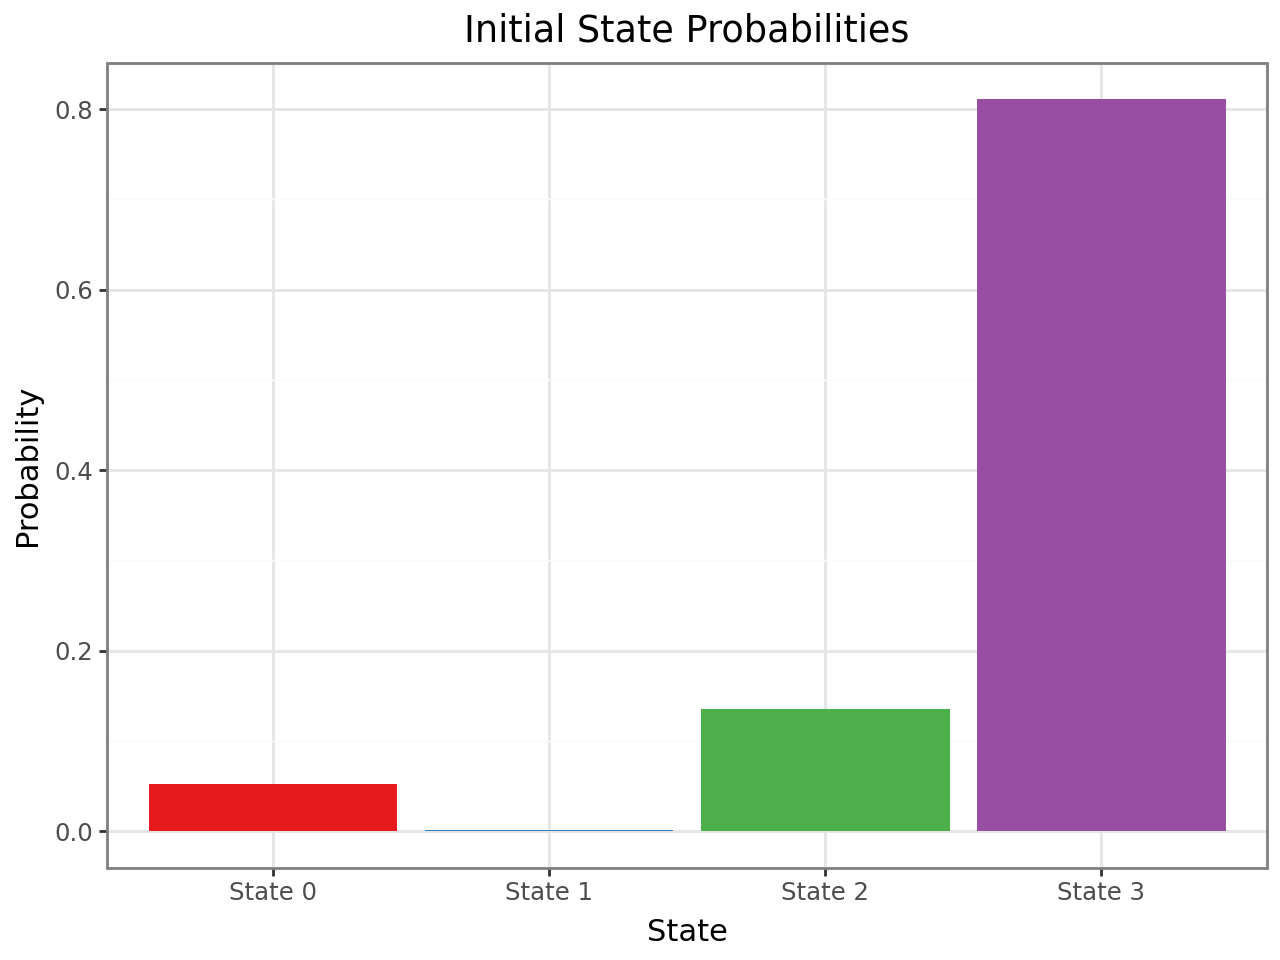

In [12]:
plots["init"]

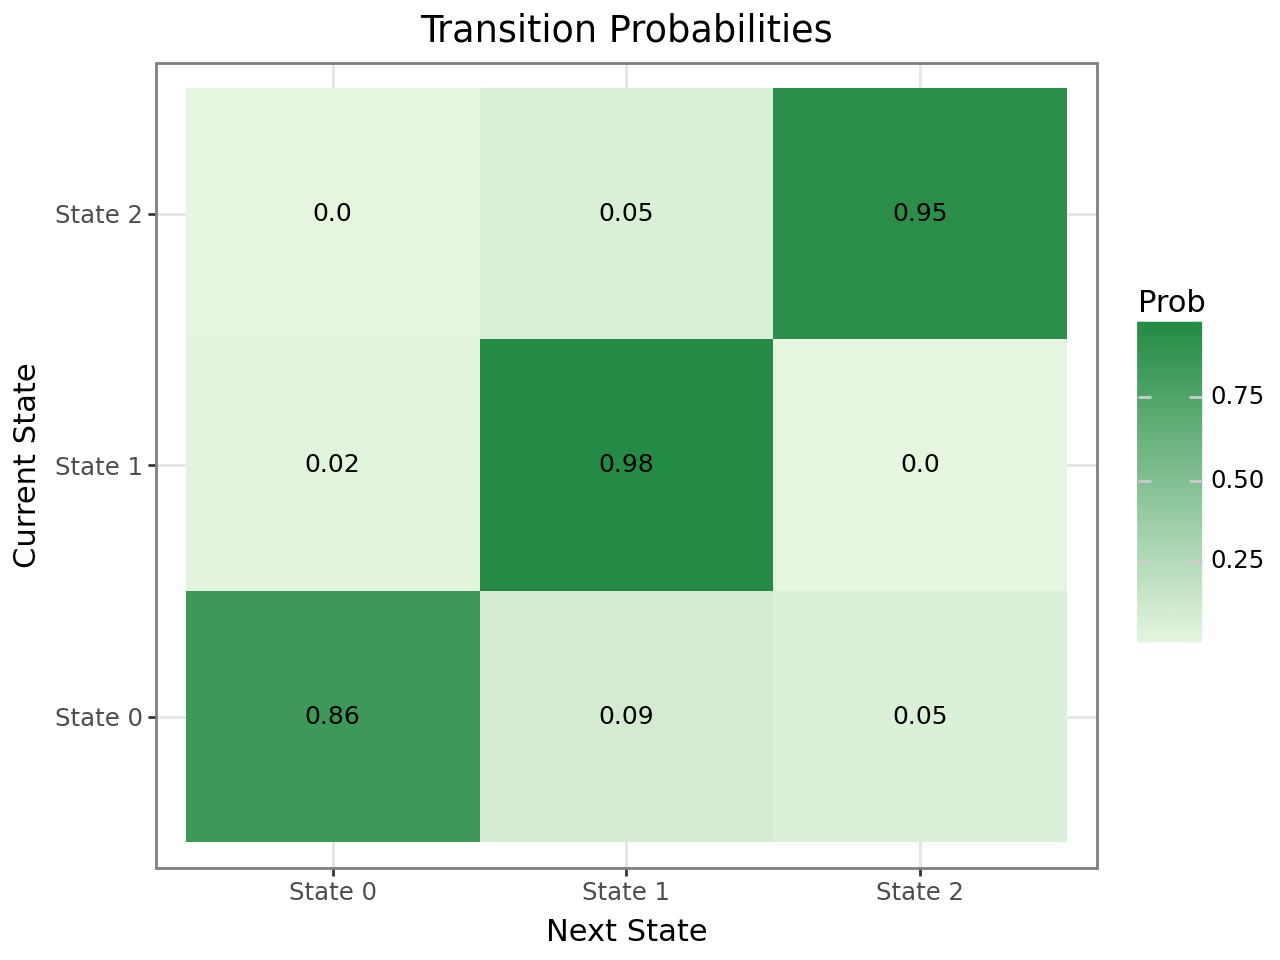

In [11]:
plots["trans"]

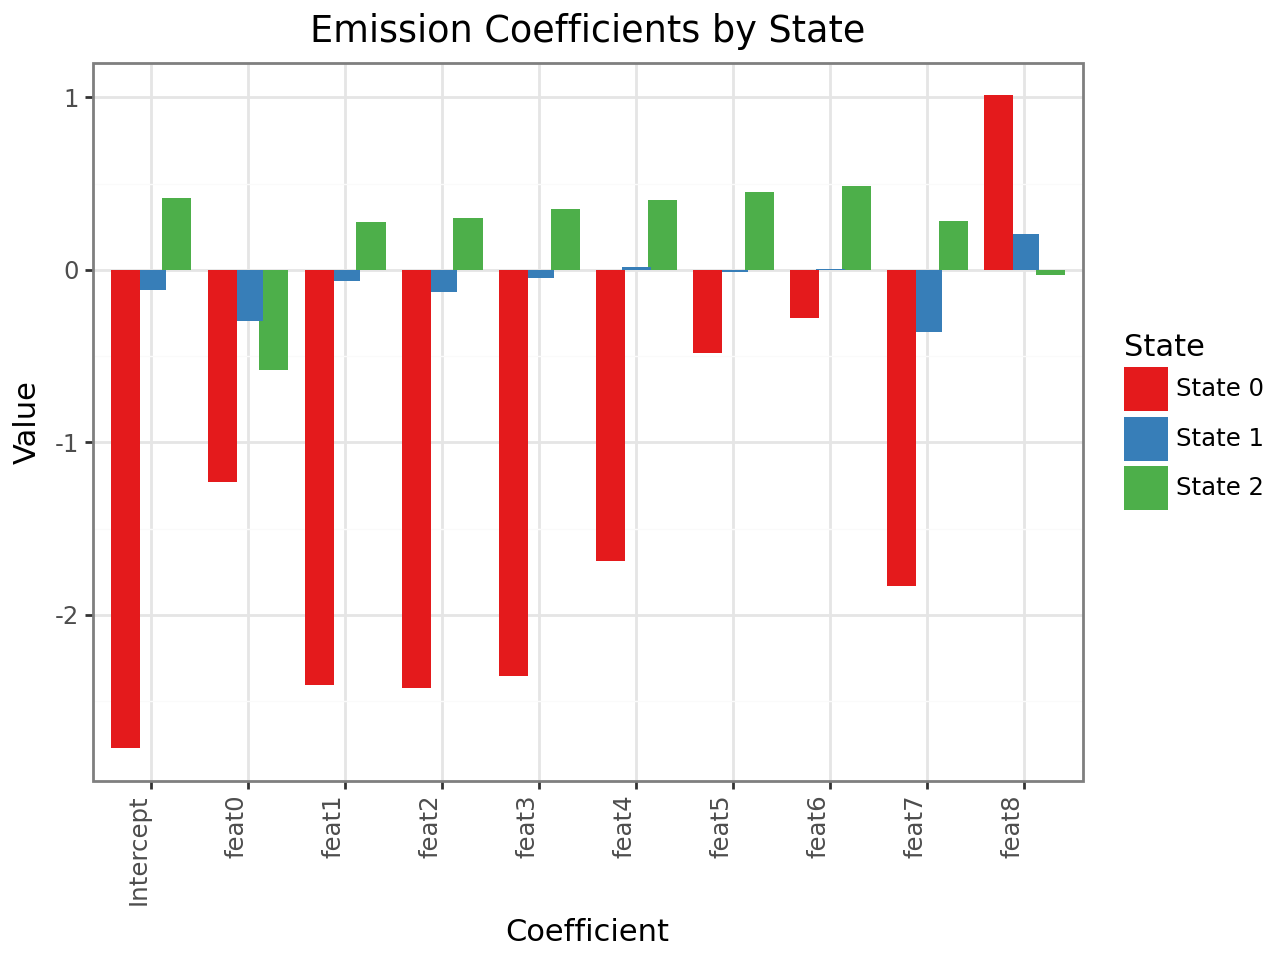

In [12]:
plots["coeffs"]

# Viterbi Algorithm

Viterbi decoder\
Goal : for each donor find the MAP latent path $z_{0:T}^\ast$.

Plug-in parameters (posterior means)\
$$\hat\pi_k = \frac{\alpha_{\pi,k}}{\sum_{j}\alpha_{\pi,j}},\qquad
  \hat A_{kj} = \frac{\alpha_{A_{k j}}}{\sum_{j'}\alpha_{A_{k j'}}},\qquad
  \hat\lambda_k = \frac{\alpha_k}{\beta_k}.$$

Dynamic programming\
Initial step\
$$\delta_0(k)=\log\hat\pi_k+\log\text{Poisson}(y_0\mid\hat\lambda_k).$$

Recursion for $t=1,\dots,T$\
$$\delta_t(j)=\max_k\bigl[\delta_{t-1}(k)+\log\hat A_{k j}\bigr]
               +\log\text{Poisson}(y_t\mid\hat\lambda_j),$$\
$$\psi_t(j)=\arg\max_k\bigl[\delta_{t-1}(k)+\log\hat A_{k j}\bigr].$$

Back-tracking\
Start with $z_T^\ast=\arg\max_k\delta_T(k)$, then\
$z_{t-1}^\ast=\psi_t(z_t^\ast)$ for $t=T,\dots,1$.

Cost $O(NTK^2)$ but vectorised in PyTorch, so only a loop on $t$.\
Output tensor paths\[N,T\] of integers 0…K-1, used for diagnostics and plots.


In [13]:
import torch, pyro, torch.nn.functional as F
import pyro.distributions as dist
import hmm_glm_viterbi as hmm_glm_viterbi

def log_softmax_logits(logits, dim=-1):
    return logits - logits.logsumexp(dim, keepdim=True)


In [14]:
paths = hmm_glm_viterbi.viterbi_paths_cov(
    obs_torch,
    cov_init_torch,    # (N,C_pi)
    cov_tran_torch,    # (N,T,C_A)
    cov_emiss_torch    # (N,T,C_em)
)
switch_rate = (paths[:, 1:] != paths[:, :-1]).any(1).float().mean()
print(f"switch rate = {switch_rate:.2%}")

switch rate = 79.67%


## State occupancy over time (population view)

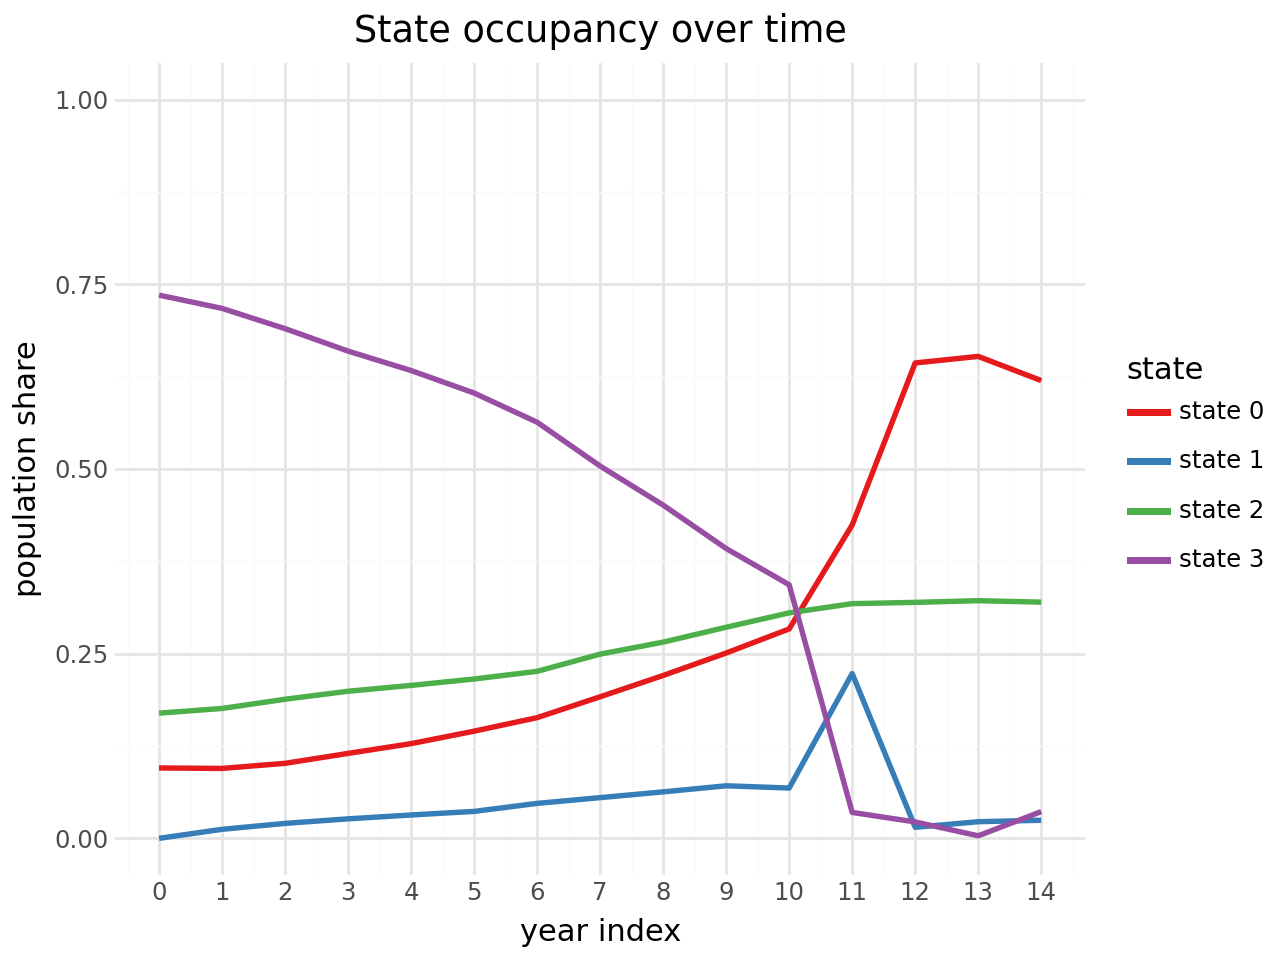

In [15]:
from plotnine import (
    ggplot, aes, geom_line,
    scale_color_manual, scale_x_continuous, scale_y_continuous,
    labs, theme_minimal, theme, element_text
)

# Accept torch.Tensor or numpy array for `paths` (shape: N,T)
paths_np = paths.detach().cpu().numpy() if hasattr(paths, "detach") else np.asarray(paths)
N, T = paths_np.shape
K = int(paths_np.max()) + 1 if paths_np.size else 1

# Counts per state over time -> (K,T)
counts = np.stack([(paths_np == k).sum(axis=0) for k in range(K)], axis=0)
props = counts / np.maximum(counts.sum(axis=0, keepdims=True), 1)  # avoid div-by-zero

# Build tidy DataFrame
rows = []
for k in range(K):
    for t in range(T):
        rows.append({"t": t, "state": f"state {k}", "share": float(props[k, t])})
df = pd.DataFrame(rows)

# Palette (match original order for K=3)
if K == 3:
    state_cols = ["#ff7f0e", "#1f77b4", "#2ca02c"]  # tab:orange, tab:blue, tab:green
else:
    base = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','#ffff33',
            '#a65628','#f781bf','#999999',"#68caab",'#fc8d62','#8da0cb',
            '#e78ac3','#a6d854','#ffd92f']
    state_cols = (base * ((K + len(base) - 1)//len(base)))[:K]

(ggplot(df, aes("t", "share", color="state"))
+ geom_line(size=1.1)
+ scale_color_manual(values=state_cols, name="state")
+ scale_x_continuous(breaks=list(range(T)))
+ scale_y_continuous(limits=(0, 1))
+ labs(x="year index", y="population share", title="State occupancy over time")
+ theme_minimal()
+ theme(axis_text_x=element_text(rotation=0)))

## Individual trajectories

Pick a few donors and overlay observations + decoded state for an easy interpretation of the model.

In [17]:
from plotnine import (
    ggplot, aes, geom_point, geom_step,
    scale_color_manual, scale_x_continuous, scale_y_continuous,
    labs, theme_minimal, theme, element_text, element_line, element_blank,
    guides, guide_legend
)
import hmm_glm_plots as hmm_glm_plots

In [19]:
# ------------------------------------------------------------
# globals (kept similar to original)
# ------------------------------------------------------------
K_default   = 3
state_cols_default = ['#e41a1c', '#377eb8', '#4daf4a']  # 3 Set1 colors
years_axis  = np.arange(2009, 2024)                    # 2009 .. 2023
yticks_vals = np.arange(0, 5)                          # 0 .. 4    

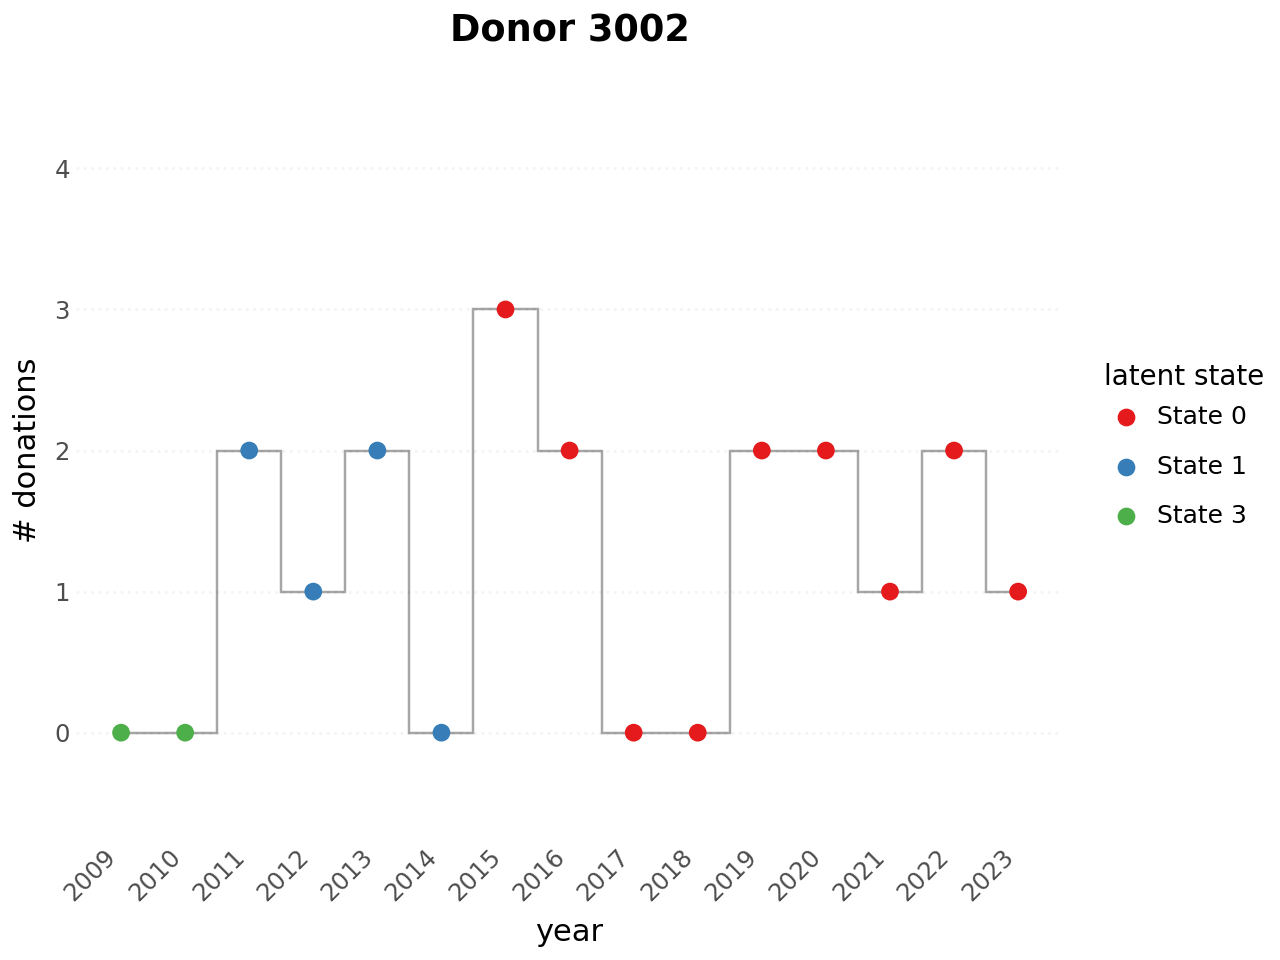

In [20]:
hmm_glm_plots.plot_one_gg(
        idx=3002,
        obs_torch=obs_torch,
        paths=paths,
        years=years_axis,
        state_cols=state_cols_default,
        y_max=4
    )

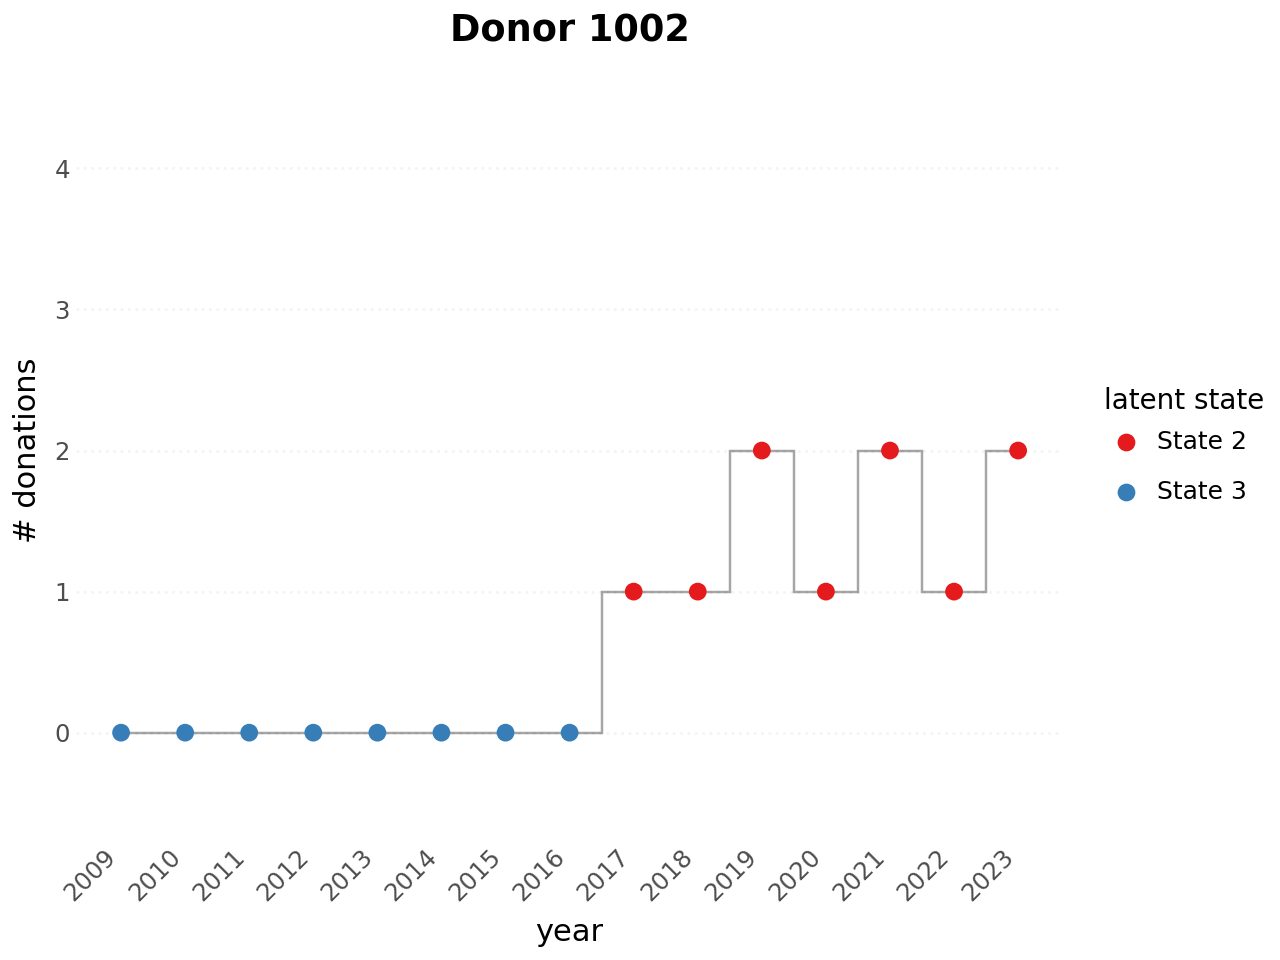

In [21]:
hmm_glm_plots.plot_one_gg(
        idx=1002,
        obs_torch=obs_torch,
        paths=paths,
        years=years_axis,
        state_cols=state_cols_default,
        y_max=4
    )

# Covariates

In [26]:
import hmm_glm_plots as hmm_glm_plots

In [ ]:
K, C_pi = W_pi.shape            # K stati, 2 covariate per π
_, _, C_A = W_A.shape           # 2 covariate per A

# ───────── 2. nomi covariate (adatta se necessario) ─────────
cov_names_pi = ["birth_year_norm", "gender_code"]             # C_pi = 2
cov_names_A  = ["ages_norm",       "covid_years"]             # C_A  = 2

state_cols = ['#e41a1c', '#377eb8', '#4daf4a']                # colori Set1

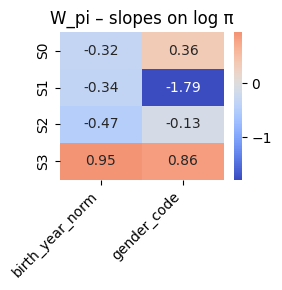

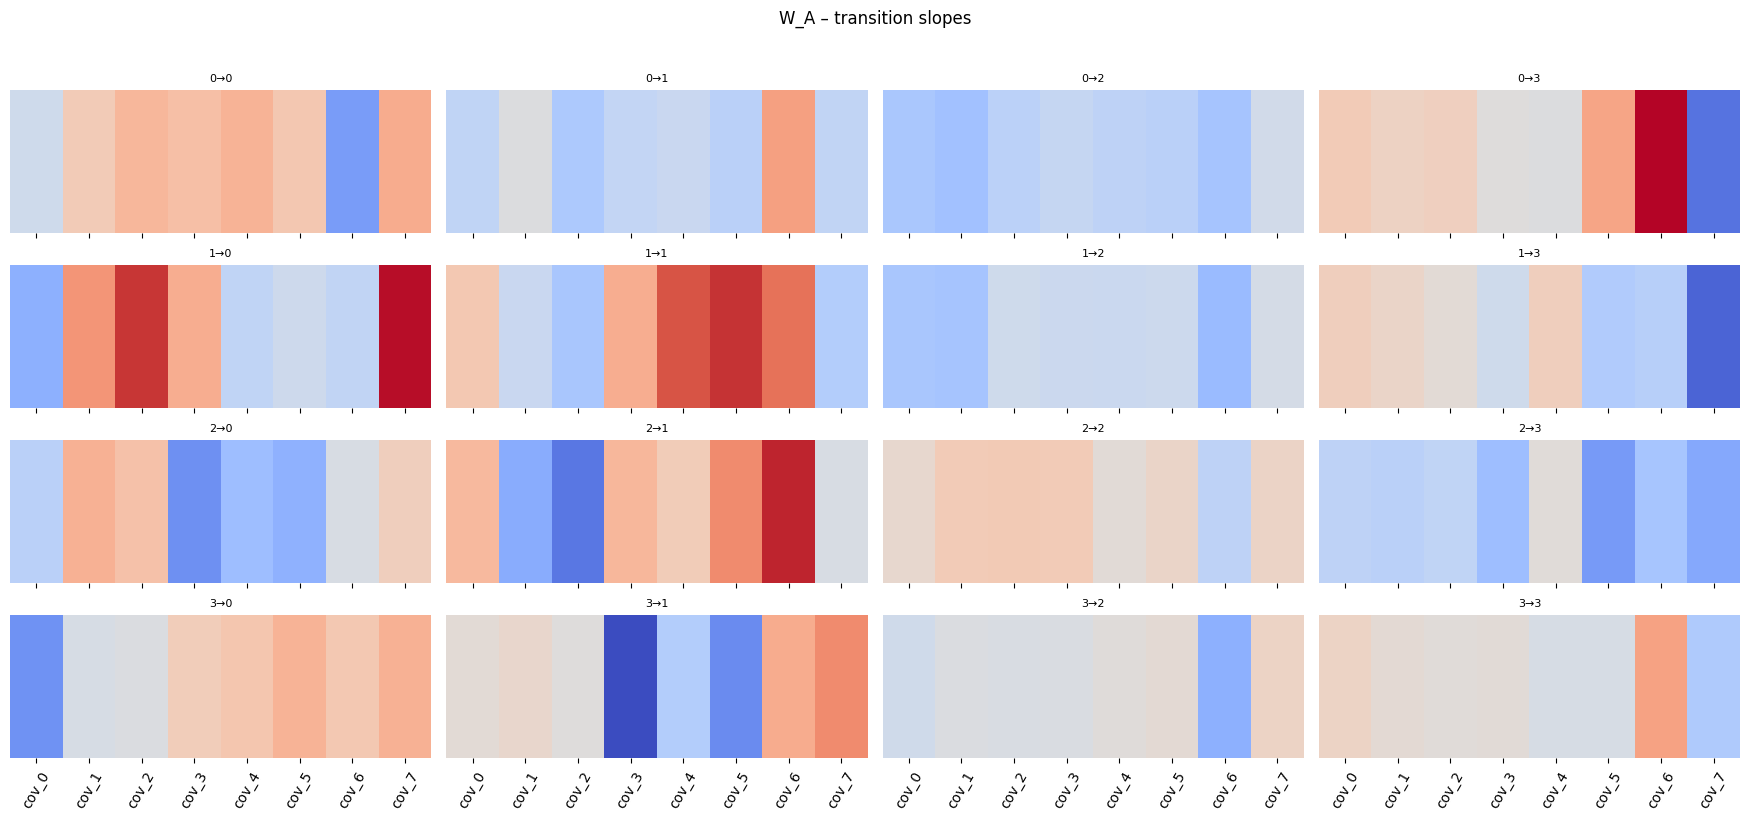

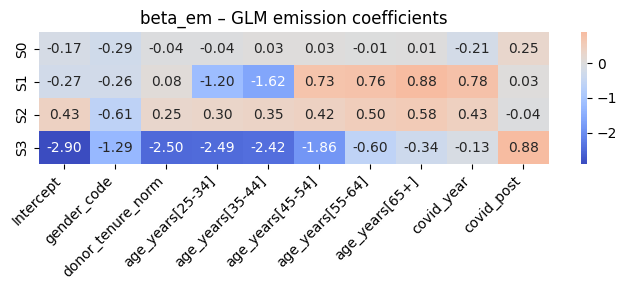

In [29]:
# Esempio: age_years è un fattore con livelli; è stato codificato a dummies
age_years_levels = ["<25","25-34","35-44","45-54","55-64","65+"]
ref_age_level = "<25"   # se hai usato one-hot con base, metti il livello di riferimento

# Covariate per A: espansione fattoriale + altre
age_fac_cols = hmm_glm_plots.expand_factor_names("age_years", age_years_levels, ref_level=ref_age_level)
# Aggiungi altre covariate di transizione (es. covid_years, trend, ecc.)
cov_names_A = age_fac_cols + ["covid_years"]

# Covariate per emissioni (GLM): possono includere fattori e continui
# Esempio: stato civile fattoriale + age_years fattoriale + indicatori covid
marital_levels = ["S","M","D","W"]
ref_marital = "S"
marital_cols = hmm_glm_plots.expand_factor_names("marital", marital_levels, ref_level=ref_marital)

em_age_fac_cols = hmm_glm_plots.expand_factor_names("age_years", age_years_levels, ref_level=ref_age_level)
cov_names_em = ["gender_code", "donor_tenure_norm"] + em_age_fac_cols + ["covid_year", "covid_post"]

# Nota importante:
# - L’ordine e il numero dei nomi devono combaciare con le colonne effettive
#   usate in training per W_A e beta_em. Se non coincidono, riadatta le liste sopra.

# ===================== 6) Chiamate ai plot ================================
hmm_glm_plots.plot_W_pi_heat(W_pi, cov_names_pi)
hmm_glm_plots.plot_W_A_heat(W_A, cov_names_A)
hmm_glm_plots.plot_beta_em_heat(beta_em, cov_names_em)

In [31]:
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns

# ==============================================================
# 1) Statistiche per z-scoring SOLO per variabili continue
# ==============================================================

# birth-year
birth_year_orig = df["birth_year"].to_numpy()
birth_year_mean = birth_year_orig.mean()
birth_year_std  = birth_year_orig.std()

# ages (N×T) costruite da birth_year e anni di calendario
years_num = np.array([int(c[2:]) for c in sorted([c for c in df.columns if c.startswith("y_")])])
ages      = years_num[None, :] - df["birth_year"].to_numpy()[:, None]
ages_mean = ages.mean()
ages_std  = ages.std()

# mean / std usate per z-scoring delle sole continue
stats = {
    "birth_year_norm": (birth_year_mean, birth_year_std),
    "ages_norm":       (ages_mean,        ages_std),
    # aggiungi qui altre variabili continue normalizzate se presenti
}

KeyError: 'birth_year'

In [ ]:


# def to_norm(var_name: str, x_orig: np.ndarray) -> np.ndarray:
#     """
#     Convert ORIGINAL values -> z-scored scale (per continue).
#     I fattori restano invariati (gestiti via dummies).
#     """
#     if var_name in stats:
#         mu, sd = stats[var_name]
#         return (x_orig - mu) / sd
#     return x_orig  # binarie o fattoriali gestite a parte

# ==============================================================
# 2) Gestione fattori (one-hot con riferimento)
# ==============================================================

# def build_factor_cols(cov_names, factor_name, levels, ref_level):
#     """
#     Ricostruisce l'indice delle colonne dummificate per un fattore:
#     cerca pattern 'factor_name[LEVEL]' in cov_names.
#     Ritorna: dict {level -> col_index or None se livello è la base (reference)}.
#     """
#     name_to_idx = {n: i for i, n in enumerate(cov_names)}
#     mapping = {}
#     for lev in levels:
#         col_name = f"{factor_name}[{lev}]"
#         if lev == ref_level:
#             mapping[lev] = None  # livello di riferimento → tutte dummies a 0
#         else:
#             if col_name not in name_to_idx:
#                 raise ValueError(f"Manca la colonna dummy {col_name} in cov_names.")
#             mapping[lev] = name_to_idx[col_name]
#     return mapping

# def set_factor_level_in_vector(x_vec, factor_map, all_dummy_indices, level):
#     """
#     Imposta in-place il livello del fattore in un vettore design.
#     - azzera tutte le dummies del fattore
#     - se level ha una colonna dedicata, la pone a 1 (altrimenti resta tutto 0 → riferimento)
#     """
#     x_vec[all_dummy_indices] = 0.0
#     idx = factor_map[level]
#     if idx is not None:
#         x_vec[idx] = 1.0

# # ==============================================================
# # 3) ORIGINAL values per covariate (continui, binari, fattori)
# # ==============================================================

# def original_values(var_name: str,
#                     factor_levels: dict | None = None,
#                     df=df,
#                     ages_matrix=ages) -> np.ndarray:
#     """
#     Restituisce valori ORIGINALI per la covariata richiesta.
#     - Se fattore: ritorna l’elenco livelli (array di stringhe).
#     - Se continuo: ritorna i valori originali.
#     - Se binario: ritorna [0., 1.].
#     factor_levels: opzionale, es. {"age_years": ["<25","25-34",...]}
#     """
#     # continue note
#     if var_name == "birth_year_norm":
#         return df["birth_year"].to_numpy()
#     if var_name == "ages_norm":
#         return ages_matrix.reshape(-1)

#     # binarie note
#     if var_name == "gender_code":
#         return np.array([0.0, 1.0])
#     if var_name == "covid_years":
#         return np.array([0.0, 1.0])

#     # fattori: prendi i livelli dichiarati
#     if factor_levels and var_name in factor_levels:
#         return np.array(factor_levels[var_name], dtype=object)

#     # fallback: se esiste come colonna fattoriale in df
#     if var_name in df.columns and (df[var_name].dtype == "category" or df[var_name].dtype == object):
#         return np.array(sorted(pd.unique(df[var_name].astype(str))), dtype=object)

#     raise ValueError(f"Unknown covariate {var_name}")

# ==============================================================
# 4) Softmax helper
# ==============================================================



# ==============================================================
# 5) π_k(x) vs covariata (original scale), con fattori e continui
# ==============================================================

def plot_pi_vs_cov_orig(
    var,
    cov_names_pi,
    W_pi,
    log_pi0,
    x_pi_data=None,               # (N, C_pi) già normalizzata
    x_pi_ref=None,                # (C_pi,) opzionale, se vuoi un reference fisso
    factor_specs_pi=None,         # dict: { "age_years": {"levels":[...], "ref":"<25"} , ... }
    grid_orig=None,
    state_cols=None,
    title_prefix="Initial-state probability vs "
):
    """
    Disegna π_k(x) al variare di una covariata (continua o fattore).
    - Per continue: curva.
    - Per fattori: punti/bars per livello.
    """
    K = W_pi.shape[0]
    if state_cols is None:
        state_cols = ['#e41a1c', '#377eb8', '#4daf4a'][:K]

    # Base/reference vector sullo spazio normalizzato
    if x_pi_ref is None:
        if x_pi_data is None:
            # prova a recuperare da torch → numpy se disponibile
            if "cov_init_torch" in globals():
                x_pi_data = cov_init_torch.cpu().numpy()
            elif "x_pi_data" in globals():
                x_pi_data = globals()["x_pi_data"]
            else:
                raise ValueError("Serve x_pi_data (o x_pi_ref) per definire il vettore di riferimento.")
        x_ref_norm = x_pi_data.mean(0)   # (C_pi,)
    else:
        x_ref_norm = x_pi_ref.copy()

    # Rileva se var è fattore
    is_factor = factor_specs_pi is not None and var in factor_specs_pi

    if is_factor:
        # specifiche fattore
        levels = factor_specs_pi[var]["levels"]
        ref    = factor_specs_pi[var]["ref"]
        # mappa livello -> indice colonna (None per ref)
        factor_map = build_factor_cols(cov_names_pi, var, levels, ref)
        # indici delle colonne dummificate di questo fattore (tutte le non-ref)
        dummy_indices = [idx for idx in factor_map.values() if idx is not None]
        grid_levels = levels if grid_orig is None else grid_orig  # lista livelli

        # calcolo π per ogni livello
        curves = []
        for lev in grid_levels:
            x_norm = x_ref_norm.copy()
            set_factor_level_in_vector(x_norm, factor_map, dummy_indices, lev)
            logits = log_pi0 + W_pi @ x_norm
            curves.append(softmax(logits))
        curves = np.vstack(curves)  # (G, K)

        # plot (bar/points per livello)
        fig, ax = plt.subplots(figsize=(7, 3.2))
        x_pos = np.arange(len(grid_levels))
        width = 0.8 / K
        for k, c in enumerate(state_cols):
            ax.bar(x_pos + k*width - 0.4 + width*K/2, curves[:, k], width=width, color=c, label=f"state {k}")
        ax.set_xticks(x_pos); ax.set_xticklabels(grid_levels, rotation=45, ha="right")
        ax.set_ylabel("π_k(x)")
        ax.set_title(f"{title_prefix}{var}")
        ax.grid(axis="y", ls=":", alpha=0.4)
        ax.legend()
        plt.tight_layout(); plt.show()

    else:
        # continua/binaria singola colonna già in cov_names_pi
        if var not in cov_names_pi:
            raise ValueError(f"{var} non è nei cov_names_pi e non risulta specificato come fattore.")
        idx = cov_names_pi.index(var)
        col_orig = original_values(var)
        # griglia ORIGINAL
        if grid_orig is None:
            uniq = np.unique(col_orig)
            grid_orig = uniq if len(uniq) <= 6 else np.linspace(col_orig.min(), col_orig.max(), 41)

        curves = []
        for v_orig in grid_orig:
            x_norm      = x_ref_norm.copy()
            x_norm[idx] = to_norm(var, v_orig)
            logits      = log_pi0 + W_pi @ x_norm
            curves.append(softmax(logits))
        curves = np.vstack(curves)  # (G, K)

        # plot (curva/linea)
        for k, c in enumerate(state_cols):
            plt.plot(grid_orig, curves[:, k], color=c, label=f"state {k}")
        plt.xlabel(var.replace("_norm", ""));  plt.ylabel("π_k(x)")
        plt.title(f"{title_prefix}{var.replace('_norm', '')}")
        plt.grid(ls=":", alpha=0.5);  plt.legend();  plt.tight_layout();  plt.show()

# ==============================================================
# 6) λ_k(x_em) del GLM emissioni vs covariata (fattori/continui)
# ==============================================================

# def plot_lambda_em_vs_cov(
#     var_em,
#     beta_em,                # (K, 1 + C_em)
#     cov_names_em,           # lunghezza = C_em
#     x_em_data=None,         # (N, T, C_em) o (N, C_em) per media di riferimento
#     x_em_ref=None,          # (C_em,) opzionale
#     factor_specs_em=None,   # dict: { "age_years": {"levels":[...], "ref":"<25"} , ... }
#     grid_orig=None,
#     state_cols=None,
#     title_prefix="Emission GLM λ_k vs "
# ):
#     """
#     Plotta la λ_k = exp(b0_k + x_em · B_k) variando una sola covariata di emissione.
#     Gestisce sia continui che fattori (dummies con riferimento).
#     """
#     K, P = beta_em.shape
#     C_em = P - 1
#     if state_cols is None:
#         state_cols = ['#e41a1c', '#377eb8', '#4daf4a'][:K]

#     # reference su x_em
#     if x_em_ref is None:
#         if x_em_data is None:
#             if "cov_emiss_torch" in globals():
#                 X = cov_emiss_torch.cpu().numpy()
#                 x_em_ref = X.mean(axis=(0, 1))  # media su N,T
#             else:
#                 raise ValueError("Serve x_em_data o x_em_ref per definire il vettore di riferimento.")
#         else:
#             X = x_em_data
#             if X.ndim == 3:
#                 x_em_ref = X.mean(axis=(0, 1))
#             elif X.ndim == 2:
#                 x_em_ref = X.mean(axis=0)
#             else:
#                 raise ValueError("x_em_data deve essere (N,T,C_em) o (N,C_em).")

#     b0 = beta_em[:, 0]      # (K,)
#     B  = beta_em[:, 1:]     # (K, C_em)

#     # fattore?
#     is_factor = factor_specs_em is not None and var_em in factor_specs_em

#     if is_factor:
#         levels = factor_specs_em[var_em]["levels"]
#         ref    = factor_specs_em[var_em]["ref"]
#         # ricostruisci mappa livello->indice colonna
#         fac_map = build_factor_cols(cov_names_em, var_em, levels, ref)
#         dummy_idx = [i for i in fac_map.values() if i is not None]
#         grid_levels = levels if grid_orig is None else grid_orig

#         lam = np.zeros((len(grid_levels), K))
#         for g, lev in enumerate(grid_levels):
#             x_ref = x_em_ref.copy()
#             # azzera dummies e setta il livello
#             if dummy_idx:
#                 x_ref[dummy_idx] = 0.0
#             idx = fac_map[lev]
#             if idx is not None:
#                 x_ref[idx] = 1.0
#             eta = b0 + B @ x_ref
#             lam[g] = np.exp(eta)

#         # plot bar per stato
#         x_pos = np.arange(len(grid_levels))
#         width = 0.8 / K
#         fig, ax = plt.subplots(figsize=(7, 3.2))
#         for k, c in enumerate(state_cols):
#             ax.bar(x_pos + k*width - 0.4 + width*K/2, lam[:, k], width=width, color=c, label=f"state {k}")
#         ax.set_xticks(x_pos); ax.set_xticklabels(grid_levels, rotation=45, ha="right")
#         ax.set_ylabel("λ_k")
#         ax.set_title(f"{title_prefix}{var_em}")
#         ax.grid(axis="y", ls=":", alpha=0.4)
#         ax.legend()
#         plt.tight_layout(); plt.show()

#     else:
#         # continuo / binario singolo
#         if var_em not in cov_names_em:
#             raise ValueError(f"{var_em} non è in cov_names_em e non risulta specificato come fattore.")
#         j = cov_names_em.index(var_em)
#         # griglia ORIGINAL (niente z-score: emissioni GLM usano la scala del design)
#         if grid_orig is None:
#             # prova a inferire dal campione se disponibile
#             if x_em_data is not None:
#                 X = x_em_data
#                 vals = X.reshape(-1, X.shape[-1])[:, j]
#                 uniq = np.unique(vals)
#                 grid_orig = uniq if len(uniq) <= 6 else np.linspace(vals.min(), vals.max(), 41)
#             else:
#                 # fallback generico
#                 grid_orig = np.linspace(-2, 2, 41)

#         lam = np.zeros((len(grid_orig), K))
#         for g, v in enumerate(grid_orig):
#             x_ref = x_em_ref.copy()
#             x_ref[j] = v
#             eta = b0 + B @ x_ref
#             lam[g] = np.exp(eta)

#         for k, c in enumerate(state_cols):
#             plt.plot(grid_orig, lam[:, k], color=c, label=f"state {k}")
#         plt.xlabel(var_em); plt.ylabel("λ_k")
#         plt.title(f"{title_prefix}{var_em}")
#         plt.grid(ls=":", alpha=0.5); plt.legend(); plt.tight_layout(); plt.show()



In [32]:
# 1) Costruisci i label delle classi d’età dai break che hai usato
#    (devono essere gli stessi usati per ages_onehot / cov_tran / cov_emission)
age_bins = np.array([18, 26, 36, 46, 56, 61, 66, 200])  # 18–25, 26–35, 36–45, 46–55, 56–60, 61–65, 66+
def age_labels_from_bins(edges):
    labs = []
    for a, b in zip(edges[:-2], edges[1:-1]):
        labs.append(f"{a}-{b-1}")  # intervalli [a,b)
    labs.append(f"{edges[-2]}+")   # ultimo aperto in alto
    return labs

age_levels = age_labels_from_bins(age_bins)  # ['18-25','26-35','36-45','46-55','56-60','61-65','66+']

# 2) Specifiche fattori
#    - π: non hai fattori (solo birth_year_norm, gender_code), quindi vuoto.
#    - Emissioni: age_years è fattore con tutte le dummies incluse → ref=None.
factor_specs_pi = {}  # nessun fattore in x_pi

factor_specs_em = {
    "age_years": {
        "levels": age_levels,
        "ref": None  # IMPORTANT: hai tutte le dummies, non ometti il riferimento
    }
    # se in futuro aggiungi altri fattori (es. marital), aggiungili qui
}

# 3) Nomi colonne design, allineati all’ordine con cui hai costruito i tensori
#    π: [birth_year_norm, gender_code]
cov_names_pi = ["birth_year_norm", "gender_code"]

#    A: [age_years[...]*7, covid_years] → 8 feature
cov_names_A = [f"age_years[{lab}]" for lab in age_levels] + ["covid_years"]

#    Emissioni: [gender(1), age_years(7), covid(1)] → 9 feature
cov_names_em = ["gender_code"] + [f"age_years[{lab}]" for lab in age_levels] + ["covid_years"]

# 4) Recupero parametri e reference dai tensori che hai già
import pyro
W_pi   = pyro.param("W_pi").detach().cpu().numpy()                 # (K, C_pi=2)
pi_base = pyro.param("pi_base_map").detach().cpu().numpy()         # (K,)
log_pi0 = np.log(np.clip(pi_base, 1e-30, None))                    # stabilizza

# Emissioni GLM (se presenti)
has_beta = "beta_em" in pyro.get_param_store()
if has_beta:
    beta_em = pyro.param("beta_em").detach().cpu().numpy()         # (K, 1 + C_em=9)

# Reference: medie campionarie (o passane una personalizzata)
x_pi_data = cov_init_torch.detach().cpu().numpy()                  # (N, 2)
x_em_data = cov_emiss_torch.detach().cpu().numpy()                 # (N, T, 9)


In [38]:

# 5) Esempi di chiamata ai plot (usando le funzioni che ti ho dato prima)

# π_k(x) vs birth_year_norm (continuo)
plot_pi_vs_cov_orig(
    var="birth_year_norm",
    cov_names_pi=cov_names_pi,
    W_pi=W_pi,
    log_pi0=log_pi0,
    x_pi_data=x_pi_data,
    factor_specs_pi=factor_specs_pi  # vuoto
)

# π_k(x) vs gender_code (binaria)
hmm_glm_plots.plot_pi_vs_cov_orig(
    var="gender_code",
    cov_names_pi=cov_names_pi,
    W_pi=W_pi,
    log_pi0=log_pi0,
    x_pi_data=x_pi_data,
    factor_specs_pi=factor_specs_pi
)

# λ_k(emissione) vs age_years (fattore con 7 livelli)
if has_beta:
    hmm_glm_plots.plot_lambda_em_vs_cov(
        var_em="age_years",
        beta_em=beta_em,
        cov_names_em=cov_names_em,
        x_em_data=x_em_data,              # media su N,T come reference
        factor_specs_em=factor_specs_em    # levels=age_levels, ref=None
    )

# λ_k(emissione) vs covid_years (binaria 0/1)
if has_beta:
    hmm_glm_plots.plot_lambda_em_vs_cov(
        var_em="covid_years",
        beta_em=beta_em,
        cov_names_em=cov_names_em,
        x_em_data=x_em_data
    )

NameError: name 'original_values' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pyro



# Se hai già original_values, to_norm, cov_names_pi/A/em, x_pi_data, ecc. usali.
# Altrimenti questi fallback recuperano dal ParamStore/tensori globali.

def get_W_A_and_logA():
    W_A = pyro.param("W_A").detach().cpu().numpy()          # (K,K,C_A)
    A0  = pyro.param("A_base_map").detach().cpu().numpy()   # (K,K)
    log_A0 = np.log(np.clip(A0, 1e-30, None))
    return W_A, log_A0

def get_pi_params():
    W_pi   = pyro.param("W_pi").detach().cpu().numpy()                # (K,C_pi)
    pi_base = pyro.param("pi_base_map").detach().cpu().numpy()        # (K,)
    log_pi0 = np.log(np.clip(pi_base, 1e-30, None))
    return W_pi, log_pi0

def get_emission_params_and_ref(cov_emiss_torch):
    has_beta = "beta_em" in pyro.get_param_store()
    if not has_beta:
        return None, None, None
    beta_em = pyro.param("beta_em").detach().cpu().numpy()            # (K,1+C_em)
    X = cov_emiss_torch.detach().cpu().numpy()                        # (N,T,C_em)
    x_em_ref = X.mean(axis=(0,1))                                     # (C_em,)
    return beta_em, x_em_ref, X.shape[-1]

# Palette default
def default_state_cols(K):
    base = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#ffff33',
            '#a65628', '#f781bf', '#999999']
    return (base * ((K + len(base) - 1)//len(base)))[:K]

# =====================================================================
# Transition probabilities vs covariata (ORIGINAL scale, fattori ok)
# =====================================================================
def plot_trans_vs_cov_orig(
    var,
    prev_state=0,
    grid_orig=None,
    cov_names_A=None,
    x_A_data=None,        # (N,T,C_A) per vettore di riferimento (media)
    W_A=None, log_A0=None,
    factor_specs_A=None,  # es.: {"age_years": {"levels": [...], "ref": None}}
    state_cols=None
):
    # Recuperi di default se non passati
    if cov_names_A is None:
        raise ValueError("Serve cov_names_A (lista nomi colonne di A).")
    if (W_A is None) or (log_A0 is None):
        W_A, log_A0 = get_W_A_and_logA()
    if x_A_data is None:
        # prova da tensore globale
        if "cov_tran_torch" in globals():
            x_A_data = cov_tran_torch.detach().cpu().numpy()
        else:
            raise ValueError("Serve x_A_data (N,T,C_A) o cov_tran_torch globale.")
    K = W_A.shape[0]
    if state_cols is None:
        state_cols = default_state_cols(K)
    if prev_state >= K:
        raise ValueError("prev_state out of range")

    # vettore di riferimento (media su N,T)
    x_ref = x_A_data.mean(axis=(0,1)).copy()   # (C_A,)

    # Caso FATTORIALE (var è un fattore, es. "age_years")
    is_factor = (factor_specs_A is not None) and (var in factor_specs_A)
    if is_factor:
        levels = factor_specs_A[var]["levels"]
        ref    = factor_specs_A[var].get("ref", None)
        factor_map, all_dummy_idx = build_factor_cols(cov_names_A, var, levels, ref)

        mats = np.zeros((len(levels), K))
        for g, lev in enumerate(levels):
            x_vec = x_ref.copy()
            set_factor_level_in_vector(x_vec, factor_map, all_dummy_idx, lev)
            logits = log_A0[prev_state] + (W_A[prev_state] @ x_vec)   # (K,)
            mats[g] = softmax(logits)

        # barplot raggruppato per j
        fig, ax = plt.subplots(figsize=(8, 3.2))
        x_pos = np.arange(len(levels))
        width = 0.8 / K
        for j, c in enumerate(state_cols):
            ax.bar(x_pos + j*width - 0.4 + width*K/2, mats[:, j], width=width, color=c, label=f"{prev_state}→{j}")
        ax.set_xticks(x_pos); ax.set_xticklabels(levels, rotation=45, ha="right")
        ax.set_ylabel("transition prob."); ax.set_xlabel(var)
        ax.set_title(f"Transition from state {prev_state} vs {var}")
        ax.grid(axis="y", ls=":", alpha=0.4); ax.legend(); plt.tight_layout(); plt.show()
        return

    # Caso CONTINUO/BINARIO (var è una singola colonna di A)
    if var not in cov_names_A:
        raise ValueError(f"{var} non trovato in cov_names_A e non specificato come fattore.")
    idx = cov_names_A.index(var)

    # grid (ORIGINALE): se binaria → {0,1}
    if grid_orig is None:
        # prova a inferire dai dati
        vals = x_A_data[..., idx].reshape(-1)
        uniq = np.unique(vals)
        grid_orig = uniq if len(uniq) <= 6 else np.linspace(vals.min(), vals.max(), 41)

    mats = np.zeros((len(grid_orig), K))
    for g, v in enumerate(grid_orig):
        x_vec = x_ref.copy()
        x_vec[idx] = v
        logits = log_A0[prev_state] + (W_A[prev_state] @ x_vec)
        mats[g] = softmax(logits)

    # line plot
    for j, c in enumerate(state_cols):
        plt.plot(grid_orig, mats[:, j], color=c, label=f"{prev_state}→{j}")
    plt.xlabel(var); plt.ylabel("transition prob.")
    plt.title(f"Transition from state {prev_state} vs {var}")
    plt.grid(ls=":"); plt.legend(); plt.tight_layout(); plt.show()

# # =====================================================================
# # Expected E[y0 | x] vs π-covariata (ORIG scale) con emissioni GLM
# # =====================================================================
# def expected_y_orig(
#     var,
#     grid_orig=None,
#     cov_names_pi=None,
#     x_pi_data=None,    # (N, C_pi) normalizzate (come in training)
#     W_pi=None, log_pi0=None,
#     rates=None,                 # fallback se non c’è beta_em
#     cov_names_em=None,
#     cov_emiss_torch=None        # per x_em_ref medio
# ):
#     # parametri π
#     if cov_names_pi is None:
#         raise ValueError("Serve cov_names_pi (lista nomi colonne di π).")
#     if (W_pi is None) or (log_pi0 is None):
#         W_pi, log_pi0 = get_pi_params()
#     if x_pi_data is None:
#         if "cov_init_torch" in globals():
#             x_pi_data = cov_init_torch.detach().cpu().numpy()
#         else:
#             raise ValueError("Serve x_pi_data o cov_init_torch globale.")
#     K = W_pi.shape[0]

#     # emissioni: GLM se disponibile, altrimenti rates
#     beta_em, x_em_ref, C_em = (None, None, None)
#     if "beta_em" in pyro.get_param_store():
#         if (cov_names_em is None) or (cov_emiss_torch is None):
#             raise ValueError("Per emissioni GLM servono cov_names_em e cov_emiss_torch.")
#         beta_em, x_em_ref, C_em = get_emission_params_and_ref(cov_emiss_torch)
#         b0 = beta_em[:, 0]
#         B  = beta_em[:, 1:]
#         lam = np.exp(b0 + B @ x_em_ref)   # (K,)
#     else:
#         if rates is None:
#             rates = pyro.param("rates").detach().cpu().numpy()
#         lam = rates.copy()  # (K,)

#     # griglia per var
#     if var not in cov_names_pi:
#         raise ValueError(f"{var} non è una covariata di π.")
#     idx = cov_names_pi.index(var)
#     # inferisci originale dalla colonna x_pi_data (già normalizzata) non è possibile;
#     # quindi se hai original_values(var) usala, altrimenti fai una griglia ragionevole:
#     if grid_orig is None:
#         if "original_values" in globals():
#             col_orig = original_values(var)
#             uniq = np.unique(col_orig)
#             grid_orig = uniq if len(uniq) <= 6 else np.linspace(col_orig.min(), col_orig.max(), 41)
#         else:
#             # fallback: se binaria o continuo standard
#             col_norm = x_pi_data[:, idx]
#             lo, hi = np.percentile(col_norm, [1, 99])
#             # prova a invertire z-score? Se hai to_norm inverse non disponibile, usa campione
#             grid_orig = np.linspace(lo, hi, 41)

#     # riferimento su π: media campionaria
#     x_ref = x_pi_data.mean(axis=0).copy()  # (C_pi,)
#     exp_vals = []
#     for v_orig in grid_orig:
#         # se esiste to_norm(), converte originale → z-score, altrimenti assume già pronta
#         if "to_norm" in globals():
#             v_norm = to_norm(var, v_orig)
#         else:
#             v_norm = v_orig
#         x_vec = x_ref.copy()
#         x_vec[idx] = v_norm
#         pi_x = softmax(log_pi0 + W_pi @ x_vec)     # (K,)
#         exp_vals.append(float(np.dot(pi_x, lam)))

#     plt.plot(grid_orig, exp_vals, "-o")
#     plt.xlabel(var.replace("_norm", "")); plt.ylabel("E[y₀ | x]")
#     plt.title(f"Expected count at t=0 vs {var.replace('_norm','')}")
#     plt.grid(ls=":"); plt.tight_layout(); plt.show()


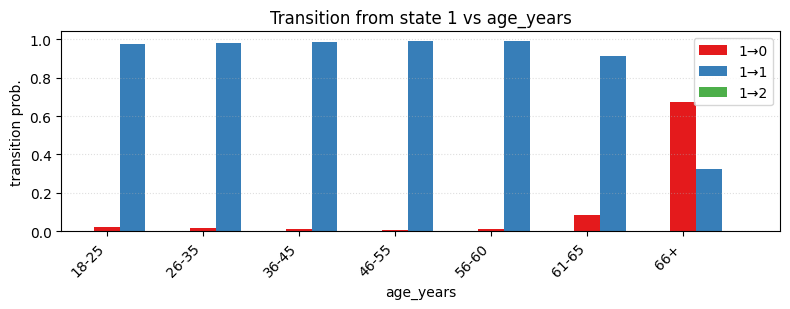

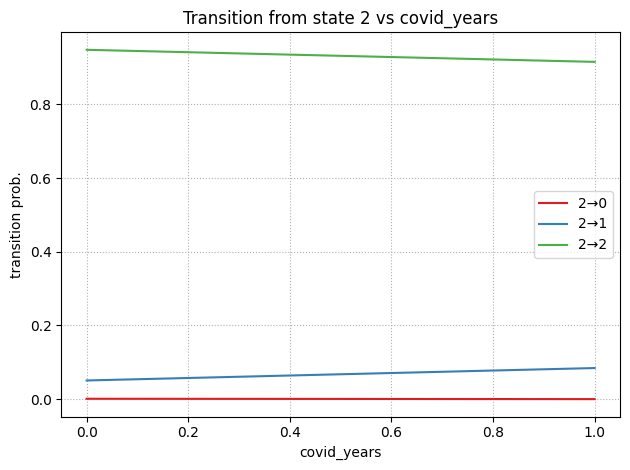

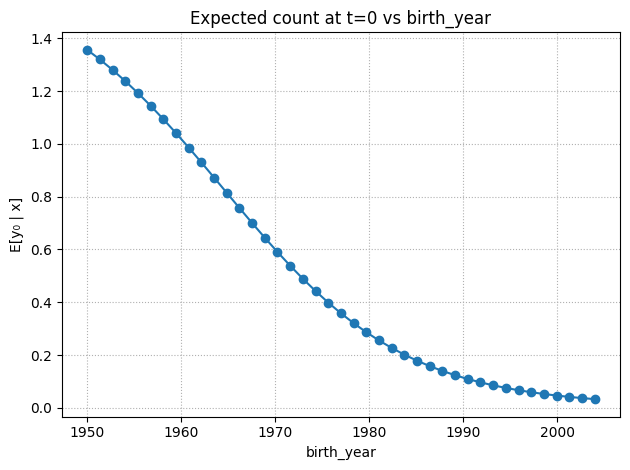

In [121]:
# 1) Specifiche fattore per A: age_years con tutte le dummies (ref=None)
age_bins = np.array([18, 26, 36, 46, 56, 61, 66, 200])
def age_labels_from_bins(edges):
    labs = []
    for a, b in zip(edges[:-2], edges[1:-1]):
        labs.append(f"{a}-{b-1}")
    labs.append(f"{edges[-2]}+")
    return labs
age_levels = age_labels_from_bins(age_bins)

factor_specs_A = {
    "age_years": {"levels": age_levels, "ref": None}
}

# 2) Nomi colonne (allineati al design che hai costruito)
#    A: [age_years[...]*7, covid_years]
cov_names_A = [f"age_years[{lab}]" for lab in age_levels] + ["covid_years"]

#    π: ["birth_year_norm", "gender_code"]
cov_names_pi = ["birth_year_norm", "gender_code"]

#    emissioni: ["gender_code"] + age dummies + ["covid_years"]
cov_names_em = ["gender_code"] + [f"age_years[{lab}]" for lab in age_levels] + ["covid_years"]

# 3) Chiamate
# Transitions vs age_years (fattore)
plot_trans_vs_cov_orig(
    var="age_years",
    prev_state=1,
    cov_names_A=cov_names_A,
    x_A_data=cov_tran_torch.detach().cpu().numpy(),
    factor_specs_A=factor_specs_A
)

# Transitions vs covid_years (binaria)
plot_trans_vs_cov_orig(
    var="covid_years",
    prev_state=2,
    cov_names_A=cov_names_A,
    x_A_data=cov_tran_torch.detach().cpu().numpy()
)

# Expected y vs π covariata (usa emissioni GLM se presenti, altrimenti rates)
W_pi, log_pi0 = get_pi_params()
expected_y_orig(
    var="birth_year_norm",
    cov_names_pi=cov_names_pi,
    x_pi_data=cov_init_torch.detach().cpu().numpy(),
    W_pi=W_pi, log_pi0=log_pi0,
    cov_names_em=cov_names_em,
    cov_emiss_torch=cov_emiss_torch  # richiesto se hai beta_em
)


In [ ]:
# Nuovo helper senza collisioni
def factor_mapping_from_names(cov_names, factor_name, levels, ref=None):
    """
    Ritorna (mapping, all_dummy_idx):
      - mapping: {level -> indice colonna o None se ref}
      - all_dummy_idx: lista di tutti gli indici dummy di questo fattore
    """
    name_to_idx = {n: i for i, n in enumerate(cov_names)}
    mapping = {}
    all_dummy_idx = []
    for lev in levels:
        col = f"{factor_name}[{lev}]"
        if (ref is not None) and (lev == ref):
            mapping[lev] = None
        else:
            if col not in name_to_idx:
                raise ValueError(f"Manca la colonna dummy: {col}")
            idx = name_to_idx[col]
            mapping[lev] = idx
            all_dummy_idx.append(idx)
    return mapping, all_dummy_idx

def get_W_A_and_logA():
    W_A = pyro.param("W_A").detach().cpu().numpy()          # (K,K,C_A)
    A0  = pyro.param("A_base_map").detach().cpu().numpy()   # (K,K)
    log_A0 = np.log(np.clip(A0, 1e-30, None))
    return W_A, log_A0

def plot_trans_vs_cov_orig(
    var,
    prev_state=0,
    grid_orig=None,
    cov_names_A=None,
    x_A_data=None,        # (N,T,C_A)
    W_A=None, log_A0=None,
    factor_specs_A=None,
    state_cols=None
):
    if cov_names_A is None:
        raise ValueError("Serve cov_names_A.")
    if (W_A is None) or (log_A0 is None):
        W_A, log_A0 = get_W_A_and_logA()
    if x_A_data is None:
        x_A_data = cov_tran_torch.detach().cpu().numpy()
    K = W_A.shape[0]
    if state_cols is None:
        state_cols = default_state_cols(K)
    if prev_state >= K:
        raise ValueError("prev_state out of range")

    x_ref = x_A_data.mean(axis=(0,1)).copy()   # (C_A,)

    # Fattore (es. "age_years")
    is_factor = (factor_specs_A is not None) and (var in factor_specs_A)
    if is_factor:
        levels = factor_specs_A[var]["levels"]
        ref    = factor_specs_A[var].get("ref", None)
        factor_map, all_dummy_idx = factor_mapping_from_names(cov_names_A, var, levels, ref)

        mats = np.zeros((len(levels), K))
        for g, lev in enumerate(levels):
            x_vec = x_ref.copy()
            set_factor_level_in_vector(x_vec, factor_map, all_dummy_idx, lev)
            logits = log_A0[prev_state] + (W_A[prev_state] @ x_vec)   # (K,)
            mats[g] = softmax(logits)

        fig, ax = plt.subplots(figsize=(8, 3.2))
        x_pos = np.arange(len(levels))
        width = 0.8 / K
        for j, c in enumerate(state_cols):
            ax.bar(x_pos + j*width - 0.4 + width*K/2, mats[:, j], width=width, color=c, label=f"{prev_state}→{j}")
        ax.set_xticks(x_pos); ax.set_xticklabels(levels, rotation=45, ha="right")
        ax.set_ylabel("transition prob."); ax.set_xlabel(var)
        ax.set_title(f"Transition from state {prev_state} vs {var}")
        ax.grid(axis="y", ls=":", alpha=0.4); ax.legend(); plt.tight_layout(); plt.show()
        return

    # Continua/binaria
    if var not in cov_names_A:
        raise ValueError(f"{var} non trovato in cov_names_A e non è un fattore.")
    idx = cov_names_A.index(var)

    if grid_orig is None:
        vals = x_A_data[..., idx].reshape(-1)
        uniq = np.unique(vals)
        grid_orig = uniq if len(uniq) <= 6 else np.linspace(vals.min(), vals.max(), 41)

    mats = np.zeros((len(grid_orig), K))
    for g, v in enumerate(grid_orig):
        x_vec = x_ref.copy()
        x_vec[idx] = v
        logits = log_A0[prev_state] + (W_A[prev_state] @ x_vec)
        mats[g] = softmax(logits)

    for j, c in enumerate(state_cols):
        plt.plot(grid_orig, mats[:, j], color=c, label=f"{prev_state}→{j}")
    plt.xlabel(var); plt.ylabel("transition prob.")
    plt.title(f"Transition from state {prev_state} vs {var}")
    plt.grid(ls=":"); plt.legend(); plt.tight_layout(); plt.show()


Let's split the DB into 2 parts, one will be used for the training and the other one for the testing.
After the training of the model the test part will be used to get the probabilities about the donor and its donation the next year. 
Furthermore, we want to analyze the past latent state of the person.

In [ ]:
import blood.notebooks.hmm_glm_prediction as hmm_glm_prediction 

In [76]:
# ───────────────────────────────────────────────────────────────
#  TRAINING on 90%
# ───────────────────────────────────────────────────────────────
pyro.clear_param_store()
svi = SVI(model, guide, Adam({"lr": 5e-2}), loss=TraceEnum_ELBO(max_plate_nesting=1))

for step in range(200):
    loss = svi.step(obs_train, xpi_train, xA_train, cov_emission_train)
    if step % 200 == 0:
        print(f"{step:4d}  ELBO(train) = {loss:,.0f}")

# save the model
pyro.get_param_store().save("hmm_params.pt")
print("Fitted and saved: rates, W_pi, W_A, pi_base_map, A_base_map")


   0  ELBO(train) = 160,277
Fitted and saved: rates, W_pi, W_A, pi_base_map, A_base_map


Load the model and store the parameters

In [77]:
def load_hmm_params(paramfile="hmm_params.pt"):
    import torch
    # Add the constraints used for training the model
    safe = [
        torch.distributions.constraints._Real,
        torch.distributions.constraints._Simplex,
        torch.distributions.constraints._GreaterThan,
    ]
    try:
        torch.serialization.add_safe_globals(safe)
    except Exception:
        pass
    pyro.clear_param_store()
    pyro.get_param_store().load(paramfile)
    W_pi    = pyro.param("W_pi").detach().cpu().numpy()
    W_A     = pyro.param("W_A").detach().cpu().numpy()
    pi_base = pyro.param("pi_base_map").detach().cpu().numpy()
    A_base  = pyro.param("A_base_map").detach().cpu().numpy()
    beta_em = pyro.param("beta_em").detach().cpu().numpy()
    return W_pi, W_A, pi_base, A_base, beta_em

W_pi, W_A, pi_base, A_base, beta_em = load_hmm_params("hmm_params.pt")

In [78]:
hmm_glm_prediction.one_step_ahead_metrics(pi_base, A_base, x_A, x_em)

NameError: name 'x_A' is not defined

In [79]:
# 2) Choose device and move tensors
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

obs_test_d  = obs_test.to(device)
xpi_test_d  = xpi_test.to(device)
xA_test_d   = xA_test.to(device)

# If you trained a GLM emission model, pass x_em (cov_emission_test).
# If you trained a constant-rate emission model, omit x_em entirely.
try:
    xem_test_d = cov_emission_test.to(device)
except NameError:
    xem_test_d = None

# 3) Forward log-likelihood per sequence
if xem_test_d is not None:
    ll_test = hmm_glm_prediction.forward_loglik_cov(obs_test_d, xpi_test_d, xA_test_d, x_em=xem_test_d)
else:
    ll_test = hmm_glm_prediction.forward_loglik_cov(obs_test_d, xpi_test_d, xA_test_d)

print(f"Test mean log-likelihood per seq: {ll_test.mean().item():.3f}")

# 4) One-step-ahead predictive metrics
if xem_test_d is not None:
    metrics = hmm_glm_prediction.one_step_ahead_metrics(obs_test_d, xpi_test_d, xA_test_d, x_em=xem_test_d)
else:
    metrics = hmm_glm_prediction.one_step_ahead_metrics(obs_test_d, xpi_test_d, xA_test_d)

print("One-step-ahead metrics (test):", metrics)

# 5) (Optional) Evaluate on train set in the same way
obs_train_d = obs_train.to(device)
xpi_train_d = xpi_train.to(device)
xA_train_d  = xA_train.to(device)
try:
    xem_train_d = cov_emission_train.to(device)
except NameError:
    xem_train_d = None

if xem_train_d is not None:
    ll_train = hmm_glm_prediction.forward_loglik_cov(obs_train_d, xpi_train_d, xA_train_d, x_em=xem_train_d)
    metrics_tr = hmm_glm_prediction.one_step_ahead_metrics(obs_train_d, xpi_train_d, xA_train_d, x_em=xem_train_d)
else:
    ll_train = hmm_glm_prediction.forward_loglik_cov(obs_train_d, xpi_train_d, xA_train_d)
    metrics_tr = hmm_glm_prediction.one_step_ahead_metrics(obs_train_d, xpi_train_d, xA_train_d)

print(f"Train mean log-likelihood per seq: {ll_train.mean().item():.3f}")
print("One-step-ahead metrics (train):", metrics_tr)

NameError: name 'dist' is not defined

In [ ]:
def _softmax_np(v):
    v = v - v.max(axis=-1, keepdims=True)
    ev = np.exp(v)
    return ev / ev.sum(axis=-1, keepdims=True)

def _row_softmax_torch(logits):
    return (logits - torch.logsumexp(logits, dim=-1, keepdim=True)).exp()



Example of usage of the function:

In [80]:
# # 2) Retrieve model dims to decide builders
# beta_em = pyro.param("beta_em").detach().cpu().numpy()   # (K, 1 + C_em)
# W_A     = pyro.param("W_A").detach().cpu().numpy()       # (K, K, C_A)
C_em = beta_em.shape[1] - 1
C_A  = W_A.shape[2]

# 3) Normalization stats (must match training). Load or set them.
#    Here we show a placeholder loader; replace with your real stats file or values.
try:
    stats = np.load("norm_stats.npz")
    birth_year_mean = float(stats["birth_year_mean"])
    birth_year_std  = float(stats["birth_year_std"])
    ages_mean       = float(stats["ages_mean"])
    ages_std        = float(stats["ages_std"])
except FileNotFoundError:
    # Fallback placeholders; replace with the actual training stats
    birth_year_mean = 1975.0
    birth_year_std  = 10.0
    ages_mean       = 45.0
    ages_std        = 10.0

# 4) Example donor history
birth_year = 1985
gender = "F"
history_years   = list(range(2009, 2024))            # 2009..2023
history_counts  = [0,1,0,0,1,0,0,1,0,0,1,0,1,0,0]    # dummy counts
next_year = 2024


x_A_builder  = None if C_A == 2 else hmm_glm_prediction.make_xA_builder(C_A)
x_em_builder = None if C_em == 3 else hmm_glm_prediction.make_xem_builder(C_em)

# 6) Call predictor
out = hmm_glm_prediction.predict_donor(
    birth_year=birth_year,
    gender=gender,
    history_years=history_years,
    history_counts=history_counts,
    next_year=next_year,
    max_k=4,
    x_em_builder=x_em_builder,
    x_A_builder=x_A_builder
)

# 7) Print results
print("Years:", out["years"])
print("Counts:", out["counts"])
print("Viterbi states:", out["viterbi_states"])
print("Next year:", out["next_year"])
print("Next-state probabilities:", np.round(out["next_state_probs"], 3))
print("Expected next:", round(out["expected_next"], 3))
print("Prob donate next:", round(out["prob_donate_next"], 3))
print("PMF next:", {k: round(v, 4) for k, v in out["pmf_next"].items()})

AttributeError: module 'hmm_glm_prediction' has no attribute 'make_xA_builder'

In [61]:
# Plot with plotnine: observed counts + latent states + next-year prediction (robust)

# --------------------------
# Example usage
# --------------------------
# Suppose:
#   - obs_torch: torch.Tensor (N,T) of counts
#   - paths: array-like (N,T) Viterbi states
#   - df: polars or pandas frame with birth_year and gender_code columns
#   - predict_donor: function defined earlier (GLM emissions compatible)

# Pick a donor and define historical years (exclude the last observed year for holdout)
i = 210
years_hist = np.arange(2009, 2023)  # 2009..2022
year_next  = 2023

# Historical counts for donor i
counts_hist = obs_torch[i, :len(years_hist)].detach().cpu().numpy().tolist()

# Donor metadata (adapt to your data container)
birth_year_indiv = int(df["birth_year"][i])
gender_indiv = "F" if int(df["gender_code"][i]) == 1 else "M"

# W_A     = pyro.param("W_A").detach().cpu().numpy()       # (K, K, C_A)
# beta_em = pyro.param("beta_em").detach().cpu().numpy()   # (K, 1 + C_em)
# C_A  = W_A.shape[2]
# C_em = beta_em.shape[1] - 1

# 2) Medie delle covariate di transizione dal training (se disponibili)
try:
    xA_means = cov_tran_torch.mean(dim=(0,1)).detach().cpu().numpy().astype(np.float32)  # (C_A,)
    if xA_means.shape[0] != C_A:
        # Fallback se dimensione non allineata
        tmp = np.zeros(C_A, dtype=np.float32)
        m = min(C_A, xA_means.shape[0])
        tmp[:m] = xA_means[:m]
        xA_means = tmp
except NameError:
    xA_means = np.zeros(C_A, dtype=np.float32)



x_A_builder = hmm_glm_prediction.make_xA_builder_with_means(C_A, xA_means)

x_em_builder = None if C_em == 3 else hmm_glm_prediction.make_xem_builder_pad(C_em)

# 5) Chiamata a predict_donor con i builder
pred = hmm_glm_prediction.predict_donor(
    birth_year=birth_year_indiv,
    gender=gender_indiv,
    history_years=years_hist.tolist(),
    history_counts=counts_hist,
    next_year=year_next,
    max_k=4,
    x_A_builder=x_A_builder,
    x_em_builder=x_em_builder
)

# Actual next-year donations (first year outside 'years_hist')
y_true_next = int(obs_torch[i, len(years_hist)].detach().cpu().item())

T_hist = len(years_hist)
N = obs_torch.shape[0]

paths = np.zeros((N, T_hist), dtype=int)   # placeholder per tutti
paths[i, :] = np.asarray(pred["viterbi_states"], dtype=int)

# Ora puoi plottare
p = hmm_glm_prediction.plot_donor_gg(
    idx=i,
    obs_torch=obs_torch[:, :T_hist],
    paths=paths,
    years=years_hist,
    expected_next=pred["expected_next"],
    y_true_next=int(obs_torch[i, T_hist].detach().cpu().item()),
    next_year=year_next,
    y_max=4
)
p

KeyError: 'birth_year'

# Comparison with a GLM

## Definizione modello GLM Poisson in Pyro

- $y \sim \mathrm{Poisson}(\mu)$
- $\log \mu = \beta_0 + \beta_1 \text{birth\_year\_norm} + \beta_2 \text{gender}$

Stimiamo il **numero totale di donazioni** a persona: per confronto 1:1 con l’HMM (che fa predizione “anno dopo anno”) useremo la previsione sul test come “donazioni attese prossimo anno”.

In [ ]:
import glm_poisson
import blood.notebooks.hmm_glm_prediction as hmm_glm_prediction

In [64]:
# y_train: last-year counts, X_train: corresponding covariates
y_train = obs_train[:, -1].float()
X_train = cov_train
loss_hist = glm_poisson.fit_glm_poisson(X_train, y_train, steps=100, lr=1e-1, verbose_every=10)

step    0: loss=11023.613
step   10: loss=10700.510
step   20: loss=10664.460
step   30: loss=10654.617
step   40: loss=10654.635
step   50: loss=10651.855
step   60: loss=10650.818
step   70: loss=10650.536
step   80: loss=10650.448
step   90: loss=10650.429


## Evaluation

Save and load the model

In [65]:
pyro.get_param_store().load("glm_poisson_params.pt")
metrics_te = glm_poisson.glm_poisson_evaluate(X_test, y_test)
mu_te, p_donate_te = glm_poisson.glm_poisson_predict(X_test)
metrics_te

NameError: name 'X_test' is not defined

## Prediction with HMM

In [66]:
EPS = 1e-30

def softmax_row(x):
    x = x - x.max(axis=-1, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=-1, keepdims=True)

def load_hmm_params(path=None, return_numpy=True):
    """
    Carica dal ParamStore i parametri chiave dell'HMM con GLM emission.
    """
    if path is not None:
        pyro.get_param_store().load(path)
    ps = pyro.get_param_store()
    def to_np(x):
        return x.detach().cpu().numpy() if return_numpy else x
    W_pi    = to_np(pyro.param("W_pi"))
    W_A     = to_np(pyro.param("W_A"))
    pi_base = to_np(pyro.param("pi_base_map"))
    A_base  = to_np(pyro.param("A_base_map"))
    beta_em = to_np(pyro.param("beta_em"))
    return W_pi, W_A, pi_base, A_base, beta_em

In [70]:
# Carica parametri
W_pi, W_A, pi_base, A_base, beta_em = load_hmm_params("hmm_params.pt")

# Converte tensori PyTorch -> NumPy
obs_test_np         = obs_test.detach().cpu().numpy()
xpi_test_np         = xpi_test.detach().cpu().numpy()
xA_test_np          = xA_test.detach().cpu().numpy()
cov_emission_test_np= cov_emission_test.detach().cpu().numpy()


In [71]:
# Predici y_T (one-step ahead) usando osservazioni fino a T-1
y_pred_hmm, state_prob = hmm_glm_prediction.hmm_forward_predict(
    obs_so_far      = obs_test_np[:, :-1],     # up to T-1
    xpi             = xpi_test_np,
    xA              = xA_test_np,
    A_base          = A_base,
    W_pi            = W_pi,
    W_A             = W_A,
    pi_base         = pi_base,
    beta_em         = beta_em,
    cov_emission    = cov_emission_test_np,    # (N_test, T, C_em)
    steps_ahead     = 1
)

AttributeError: module 'hmm_glm_prediction' has no attribute 'hmm_forward_predict'

In [74]:
y_test = obs_test_np[:, -1]
print(f"HMM(full): pred mean={y_pred_hmm.mean():.2f}  obs mean={y_test.mean():.2f}")
print(f"MSE: {np.mean((y_pred_hmm - y_test)**2):.4f}")
print(f"Accuracy (round): {100*np.mean(np.round(y_pred_hmm)==y_test):.2f}%")

HMM(full): pred mean=0.57  obs mean=0.96
MSE: 1.1291
Accuracy (round): 39.87%


## Number of latent states

In [ ]:
# functioon for building model and guide with covariates and K states 
def make_hmm_model_and_guide_cov(K):
    @config_enumerate
    def model(obs, x_pi, x_A, x_em):
        # forza obs a torch.Tensor
        obs = torch.as_tensor(obs)
        N, T = obs.shape
        C_pi = x_pi.shape[1]
        C_A  = x_A.shape[2]
        C_em = x_em.shape[2]

        # Priors
        alpha_pi = 0.5 * torch.ones(K)        # <1 → più “spiky”
        alpha_A  = torch.full((K, K), 0.5)
        alpha_A.fill_diagonal_(6.0)           # forte massa in diagonale
        
        pi_base = pyro.sample("pi_base", dist.Dirichlet(alpha_pi))             # [K]
        A_base  = pyro.sample("A_base",  dist.Dirichlet(alpha_A).to_event(1))  # [K,K]
        
        log_pi_base = pi_base.log()
        log_A_base  = A_base.log()

        # Parametri globali
        W_pi  = pyro.param("W_pi", 0.01 * torch.randn(K, C_pi))
        W_A   = pyro.param("W_A",  0.01 * torch.randn(K, K, C_A))
        beta_em = pyro.param("beta_em", 0.01 * torch.randn(K, C_em + 1))
        
        with pyro.plate("seqs", N):
            # stato iniziale
            logits0 = log_pi_base + (x_pi @ W_pi.T)
            z_prev = pyro.sample("z_0", dist.Categorical(logits=logits0),
                                infer={"enumerate": "parallel"})
            
            log_mu_0 = beta_em[z_prev, 0] + (x_em[:, 0, :] * beta_em[z_prev, 1:]).sum(-1)
            pyro.sample("y_0", dist.Poisson(log_mu_0.exp()), obs=obs[:, 0])

            # transizioni
            for t in range(1, T):
                x_t = x_A[:, t, :]
                
                logitsT = (log_A_base[z_prev] + (W_A[z_prev] * x_t[:, None, :]).sum(-1))
                z_t = pyro.sample(f"z_{t}", dist.Categorical(logits=logitsT),
                                infer={"enumerate": "parallel"})
                
                log_mu_t = beta_em[z_t, 0] + (x_em[:, t, :] * beta_em[z_t, 1:]).sum(-1)
                pyro.sample(f"y_{t}", dist.Poisson(log_mu_t.exp()), obs=obs[:, t])
                
                z_prev = z_t
        
      
    def guide(obs, x_pi, x_A, x_em):
        # forza obs a torch.Tensor
        obs = torch.as_tensor(obs)
        # Parametri MAP per pi e A
        pi_q = pyro.param("pi_base_map",
                        torch.ones(K) / K,
                        constraint=dist.constraints.simplex)

        A_init = torch.eye(K) * (K - 1.) + 1.
        A_init = A_init / A_init.sum(-1, keepdim=True)
        A_q = pyro.param("A_base_map",
                        A_init,
                        constraint=dist.constraints.simplex)

        pyro.sample("pi_base", dist.Delta(pi_q).to_event(1))
        pyro.sample("A_base",  dist.Delta(A_q).to_event(2))

    
    #num_params = K * x_pi.shape[1] + K * K * x_A.shape[2] + K * (x_em.shape[2] + 1) + K + K*K


    return model, guide

# Reads the variational parameters from the ParamStore and returns point estimates.
@torch.no_grad()
def extract_posterior_point_estimates_cov():
    
    store = pyro.get_param_store()

    def softmax_row(v):
        e = np.exp(v - np.max(v, axis=-1, keepdims=True))
        return e / e.sum(axis=-1, keepdims=True)

    # 1) Extract learned parameters
    pi_base = pyro.param("pi_base_map").detach().cpu().numpy()      # (K,) simplex
    A_base  = pyro.param("A_base_map").detach().cpu().numpy()       # (K, K) rows on simplex
    W_pi    = pyro.param("W_pi").detach().cpu().numpy()             # (K, C_pi)
    W_A     = pyro.param("W_A").detach().cpu().numpy()              # (K, K, C_A)
    beta_em = pyro.param("beta_em").detach().cpu().numpy()          # (K, 1 + C_em) if intercept first


    # 2) Covariate means
    x_mean_pi = cov_init_torch.mean(dim=0).detach().cpu().numpy()        # (C_pi,)
    x_mean_A  = cov_tran_torch.mean(dim=(0, 1)).detach().cpu().numpy()   # (C_A,)
    x_mean_em = cov_emiss_torch.mean(dim=(0,1)).detach().cpu().numpy()   # (C_em,)

    print("Mean covariates (π):", x_mean_pi)
    print("Mean covariates (A):", x_mean_A)
    print("Mean covariates (emission):", x_mean_em)

    # 3) Mean initial probs, transitions and rates under average covariates
    logits_pi = np.log(pi_base + 1e-30) + W_pi @ x_mean_pi
    pi_mean   = softmax_row(logits_pi[None, :]).ravel()

    K = pi_mean.shape[0]
    A_mean = np.zeros((K, K))
    for k in range(K):
        logits_row = np.log(A_base[k] + 1e-30) + (W_A[k] @ x_mean_A)
        A_mean[k] = softmax_row(logits_row[None, :]).ravel()
   
    rates_mean = np.zeros(K)
    for k in range(K):
        log_mu = beta_em[k, 0] + np.dot(x_mean_em, beta_em[k, 1:])
        rates_mean[k] = np.exp(log_mu)

    # # 4) Names
    # state_names = [f"State {i}" for i in range(K)]

    # # Infer emission coefficient names from beta_em shape
    # C_em = beta_em.shape[1] - 1  # exclude intercept
    # coeff_names = [f"feat{i}" for i in range(C_em)]
    # include_intercept = True

    # # Optional check: ensure consistency with your covariate tensor
    # if 'cov_emiss_torch' in globals():
    #     C_em_from_tensor = int(cov_emiss_torch.shape[-1])
    #     if C_em_from_tensor != C_em:
    #         print(f"Warning: beta_em has {C_em} coefficients, but cov_emission tensor has {C_em_from_tensor} features.")

    # Calcolo rates medi per ciascuno stato

    return pi_mean, A_mean, rates_mean

# Uses the learned parameters from the ParamStore to make predictions on test data, compute MSE and Accuracy, and display a plot."
def evaluate_hmm_glm_prediction(obs_test, xpi_test, xA_test, cov_emission_test):
    
    store = pyro.get_param_store()

    def softmax_row(v):
        e = np.exp(v - np.max(v, axis=-1, keepdims=True))
        return e / e.sum(axis=-1, keepdims=True)

    # 1) Extract learned parameters
    pi_base = pyro.param("pi_base_map").detach().cpu().numpy()      # (K,)
    A_base  = pyro.param("A_base_map").detach().cpu().numpy()       # (K, K)
    W_pi    = pyro.param("W_pi").detach().cpu().numpy()             # (K, C_pi)
    W_A     = pyro.param("W_A").detach().cpu().numpy()              # (K, K, C_A)
    beta_em = pyro.param("beta_em").detach().cpu().numpy()          # (K, 1 + C_em)

    # 2) Convert test data to NumPy
    obs_test_np          = obs_test.detach().cpu().numpy()
    xpi_test_np          = xpi_test.detach().cpu().numpy()
    xA_test_np           = xA_test.detach().cpu().numpy()
    cov_emission_test_np = cov_emission_test.detach().cpu().numpy()

    # 3) One-step ahead prediction
    y_pred_hmm, state_prob = hmm_glm_prediction.hmm_forward_predict(
        obs_so_far=obs_test_np[:, :-1],
        xpi=xpi_test_np,
        xA=xA_test_np,
        A_base=A_base,
        W_pi=W_pi,
        W_A=W_A,
        pi_base=pi_base,
        beta_em=beta_em,
        cov_emission=cov_emission_test_np,
        steps_ahead=1
    )

    # 4) True values
    y_test = obs_test_np[:, -1]

    # 5) Compute metrics
    mse = np.mean((y_pred_hmm - y_test)**2)
    acc = 100*np.mean(np.round(y_pred_hmm) == y_test)

    print(f"HMM(full): pred mean={y_pred_hmm.mean():.2f}  obs mean={y_test.mean():.2f}")
    print(f"MSE: {mse:.4f}")
    print(f"Accuracy (round): {acc:.2f}%")

    # 6) Plot predictions vs observations
    plt.figure(figsize=(8,4))
    plt.scatter(range(len(y_test)), y_test, label="Observed", alpha=0.7)
    plt.scatter(range(len(y_pred_hmm)), y_pred_hmm, label="Predicted", alpha=0.7)
    plt.title("HMM GLM: One-step ahead predictions")
    plt.xlabel("Sequence index")
    plt.ylabel("Observation")
    plt.legend()
    plt.grid(True)
    plt.show()

    return y_pred_hmm, y_test, mse, acc

def log_softmax_logits(logits, dim=-1):
    return logits - torch.logsumexp(logits, dim=dim, keepdim=True)

# Computes the forward algorithm log-likelihood for a covariate-dependent HMM with Poisson emissions using the parameters stored in the Pyro ParamStore.
@torch.no_grad()
def forward_loglik_cov(obs, x_pi, x_A, x_em):
    device = obs.device
    ps = pyro.get_param_store()
    pi_base = ps["pi_base_map"].to(device)
    A_base  = ps["A_base_map"].to(device)
    W_pi    = ps["W_pi"].to(device)
    W_A     = ps["W_A"].to(device)
    beta_em = ps["beta_em"].to(device)

    N, T = obs.shape
    K = pi_base.shape[0]
    b0 = beta_em[:, 0]
    B  = beta_em[:, 1:]
    log_mu = torch.einsum("ntc,kc->ntk", x_em.to(device), B) + b0.view(1, 1, K)
    emis_log = dist.Poisson(rate=log_mu.exp()).log_prob(obs.unsqueeze(-1))  # (N,T,K)

    log_pi = log_softmax_logits(pi_base.log() + x_pi @ W_pi.T, dim=1)       # (N,K)
    log_alpha = log_pi + emis_log[:, 0]

    log_A0 = A_base.log()
    for t in range(1, T):
        x_t = x_A[:, t, :]
        logits = log_A0.unsqueeze(0) + (W_A.unsqueeze(0) * x_t[:, None, None, :]).sum(-1)
        log_A = log_softmax_logits(logits, dim=2)
        log_alpha = torch.logsumexp(log_alpha.unsqueeze(2) + log_A, dim=1) + emis_log[:, t]
    return torch.logsumexp(log_alpha, dim=1)  # (N,)


In [ ]:
def train_and_evaluate_cov(obs_torch, x_pi, x_A, x_em, K_list, n_steps=500, lr=1e-5):

    log_evidences = []
    final_elbos = []   # qui salvo gli ELBO finali per ogni K
    saved_param_files = []  # tengo traccia dei file salvati

    for K in K_list:
        print(f"\n=== Training HMM with K={K} states ===")
        
        # crea modello e guida
        model, guide = make_hmm_model_and_guide_cov(K)

        # resetta ParamStore
        pyro.clear_param_store()

        svi = SVI(model, guide,
                  Adam({"lr": lr}),
                  loss=TraceEnum_ELBO(max_plate_nesting=1))

        losses = []
        for step in range(n_steps):
            loss = svi.step(obs_torch, x_pi, x_A, x_em)
            losses.append(loss)
            if step % 50 == 0:
                print(f"K={K} | step {step:4d}  ELBO = {loss:,.0f}")
        
        # ELBO finale (prendiamo l'ultimo valore di loss, che è -ELBO)
        final_elbo_val = -losses[-1]
        final_elbos.append(final_elbo_val)

        # estrai parametri puntuali
        pi_mean, A_mean, rates_mean = extract_posterior_point_estimates_cov()
        
        params = {
            "pi_hat": torch.tensor(pi_mean, dtype=torch.float32),
            "A_hat": torch.tensor(A_mean, dtype=torch.float32),
            "rates_hat": torch.tensor(rates_mean, dtype=torch.float32)
        }

        evaluate_hmm_glm_prediction(obs_torch, x_pi, x_A, x_em)

        # calcola log-likelihood / evidenza
        log_evidence_val = forward_loglik_cov(obs_torch, x_pi, x_A, x_em).sum()
        log_evidences.append(log_evidence_val)
        print(f"Log-evidence K={K}: {log_evidence_val:.2f}")

        # 🔹 salva i parametri in file
        param_file = f"hmm_glm_params_K{K}.pt"
        pyro.get_param_store().save(param_file)
        saved_param_files.append(param_file)
        print(f"Parametri salvati in {param_file}")

    # plot
    plt.figure(figsize=(10,5))
    plt.plot(K_list, log_evidences, marker='o', label="Log-evidence")
#   plt.plot(K_list, final_elbos, marker='x', label="Final ELBO")
    plt.xlabel("Number of latent states K")
    plt.ylabel("Value")
    plt.title("Model comparison via log-evidence and ELBO")
    plt.legend()
    plt.grid(True)
    plt.show()

    return K_list, log_evidences, final_elbos, saved_param_files

K_list = range(2, 9)
K_list, log_evidences, final_elbos = train_and_evaluate_cov(obs_torch, cov_init_torch, cov_tran_torch, cov_emiss_torch, K_list, n_steps=200, lr=2e-3)

## BIC penalization

In [ ]:
C_pi = cov_init_torch.shape[1]
C_A  = cov_tran_torch.shape[2]
C_em = cov_emiss_torch.shape[2]


K_list = list(range(1, 9))
log_evidences = np.array([
    -174517.90625,
  -140057.25,
  -139246.84375,
  -138848.71875,
  -137796.09375,
  -136732.84375,
  -136524.203125,
  -135943.8125
])

# rendiamo valori positivi
#log_evidences_pos = np.abs(log_evidences)

# calcoliamo num_params per ciascun K
num_params_list = []
for K in K_list:
    num_params = K * C_pi + K * K * C_A + K * (C_em + 1) + K + K*K
    num_params_list.append(num_params)
num_params_list = np.array(num_params_list)

# numero di sequenze
N = 9236

# criterio penalizzato stile BIC
penalized = log_evidences - 0.5 * num_params_list * np.log(N)

# plot
plt.figure(figsize=(10, 5))
plt.plot(K_list, log_evidences, marker='o', label='|Log-evidence|')
plt.plot(K_list, penalized, marker='x', label='Penalized (BIC-like)')
plt.xlabel("Number of latent states K")
plt.ylabel("Value")
plt.title("Positive log-evidence and penalized criterion")
plt.grid(True)
plt.legend()
plt.show()